In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap

from lunardate import LunarDate
from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    BaggingRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, HuberRegressor, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# Block 0 - Experiement Global Config
@dataclass(frozen=True)
class ExperimentConfig:
    # Data paths
    data_path: Path = Path("data/sales_daily.csv")

    # Split ranges, inclusive YYYYMM.
    train_ym_range: tuple[int, int] = (202201, 202512)
    valid_ym_range: tuple[int, int] | None = None
    test_ym_range: tuple[int, int] = (202601, 202612)

    # Rolling daily forecast target. 
    # Max rolling daily horizon. 31 covers full next-month forecast from prior month end.
    forecast_horizon_days: int = 31

    # Evaluation anchor:
    # If eval_forecast_start_wd_seq=10, model uses information up to WD9 (9th working day)
    # and evaluates predicted daily qty from WD10 to month end.
    eval_forecast_start_wd_seq: int = 10

    # Plot one test month forecast path.
    display_bizym: int = 202601

    # Calendar behavior.
    use_chinese_calendar_if_available: bool = True
    fill_missing_daily_qty_with_zero: bool = True

    # Feature windows.
    rolling_windows: tuple[int, ...] = (3, 5, 7, 14, 30)
    lag_days: tuple[int, ...] = (1, 2, 3, 7, 14, 28)
    same_month_history_years: tuple[int, ...] = (1, 2, 3)

    # Model selection.
    random_seed: int = 42
    cv_splits: int = 3
    max_param_candidates_per_model: int = 12
    target_col: str = "target_daily_qty"

    # Metric for model selection.
    selection_metric: str = "valid_month_total_mape"

    # Numerical safety.
    eps: float = 1e-9


CONFIG = ExperimentConfig()
np.random.seed(CONFIG.random_seed)
MODEL_SPECS: dict[str, dict[str, Any]] = {
    "linear_regression": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", LinearRegression()),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__fit_intercept": [True],
        },
    },
    "ridge": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", Ridge(random_state=CONFIG.random_seed)),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__alpha": [0.001, 0.01, 0.1, 1.0, 3.0, 10.0],
        },
    },
    "lasso": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", Lasso(random_state=CONFIG.random_seed, max_iter=20000)),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__alpha": [0.001, 0.01, 0.1, 1.0],
        },
    },
    "elastic_net": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", ElasticNet(random_state=CONFIG.random_seed, max_iter=20000)),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__alpha": [0.001, 0.01, 0.1],
            "regressor__model__l1_ratio": [0.2, 0.5, 0.8],
        },
    },
    "huber": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", HuberRegressor(max_iter=2000)),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__epsilon": [1.35, 1.5, 1.75, 2.0, 2.5, 3.0],
            "regressor__model__alpha": [0.000001, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],
        },
    },
    "random_forest": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", RandomForestRegressor(random_state=CONFIG.random_seed, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [2, 3, 4, None],
            "model__min_samples_leaf": [1, 2, 4],
        },
    },
    "extra_trees": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", ExtraTreesRegressor(random_state=CONFIG.random_seed, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [2, 3, 4, None],
            "model__min_samples_leaf": [1, 2, 4],
        },
    },
    "bagging": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", BaggingRegressor(random_state=CONFIG.random_seed, n_estimators=200, n_jobs=-1)),
        ]),
        "param_grid": {
            "model__max_samples": [0.6, 0.8, 1.0],
            "model__max_features": [0.6, 0.8, 1.0],
        },
    },
    "gradient_boosting": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", GradientBoostingRegressor(random_state=CONFIG.random_seed)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3],
            "model__min_samples_leaf": [1, 3],
        },
    },
    "hist_gradient_boosting": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", HistGradientBoostingRegressor(random_state=CONFIG.random_seed)),
        ]),
        "param_grid": {
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_leaf_nodes": [7, 15, 31],
            "model__min_samples_leaf": [10, 20],
        },
    },
    "ada_boost": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", AdaBoostRegressor(random_state=CONFIG.random_seed)),
        ]),
        "param_grid": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.03, 0.1, 0.3],
        },
    },
     "xgboost": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", XGBRegressor(
                random_state=CONFIG.random_seed,
                objective="reg:squarederror",
                n_jobs=-1,
            )),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 4],
        },
    },
    "lightbgm": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", LGBMRegressor(random_state=CONFIG.random_seed, n_jobs=-1, verbosity=-1)),
        ]),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__num_leaves": [15, 31, 63],
        },
    },
    "knn": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", KNeighborsRegressor()),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__n_neighbors": [2, 3, 5, 7],
            "regressor__model__weights": ["uniform", "distance"],
        },
    },
    "svr": {
        "estimator": TransformedTargetRegressor(
            regressor=Pipeline([
                ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
                ("scaler", StandardScaler()),
                ("model", SVR()),
            ]),
            func=np.log1p,
            inverse_func=np.expm1,
        ),
        "param_grid": {
            "regressor__model__C": [0.3, 1.0, 3.0, 10.0],
            "regressor__model__epsilon": [0.01, 0.05, 0.1],
            "regressor__model__gamma": ["scale", "auto"],
        },
    },
    "decision_tree": {
        "estimator": Pipeline([
            ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
            ("model", DecisionTreeRegressor(random_state=CONFIG.random_seed)),
        ]),
        "param_grid": {
            "model__max_depth": [2, 3, 4, None],
            "model__min_samples_leaf": [1, 2, 4],
        },
    },
}


In [3]:
# Block 1 - Data Loading and Empty Fill

def resolve_data_path(path: Path) -> Path:
    candidates = [
        path,
        Path("code/30d-jenny") / path,
        Path("../../code/30d-jenny") / path,
        Path("data/sales_daily.csv"),
        Path("../../data/sales_daily.csv"),
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Cannot find data file. Tried: {[str(p) for p in candidates]}")


def build_is_workday_func(use_chinese_calendar_if_available: bool):
    if use_chinese_calendar_if_available:
        try:
            from chinese_calendar import is_workday as cn_is_workday

            return lambda ts: bool(cn_is_workday(pd.Timestamp(ts).date())), "chinese_calendar"
        except Exception:
            pass

    return lambda ts: pd.Timestamp(ts).dayofweek < 5, "weekday_fallback_mon_fri"

def to_lunar_fields(ts) -> dict[str, int]:
    from lunardate import LunarDate

    ts = pd.Timestamp(ts)
    lunar = LunarDate.fromSolarDate(ts.year, ts.month, ts.day)

    return {
        "lunar_year": lunar.year,
        "lunar_month": lunar.month,
        "lunar_day": lunar.day,
        "lunar_date": f"{lunar.year:04d}-{lunar.month:02d}-{lunar.day:02d}",
        "is_lunar_leap_month": int(bool(lunar.isLeapMonth)),
    }

def month_start_from_bizym(bizym: int) -> pd.Timestamp:
    year, month = divmod(int(bizym), 100)
    return pd.Timestamp(year=year, month=month, day=1)

def get_lunar_holiday(ts) -> str:
    ts = pd.Timestamp(ts)
    lunar = LunarDate.fromSolarDate(ts.year, ts.month, ts.day)
    next_lunar = LunarDate.fromSolarDate(
        (ts + pd.Timedelta(days=1)).year,
        (ts + pd.Timedelta(days=1)).month,
        (ts + pd.Timedelta(days=1)).day,
    )

    if next_lunar.month == 1 and next_lunar.day == 1:
        return "除夕"

    holiday_map = {
        (1, 1): "春节",
        (1, 2): "春节",
        (1, 3): "春节",
        (1, 4): "春节",
        (1, 5): "春节",
        (1, 6): "春节",
        (1, 7): "春节",
        (1, 15): "元宵",
        (5, 5): "端午",
        (7, 7): "七夕",
        (8, 15): "中秋",
        (9, 9): "重阳",
        (12, 8): "腊八",
    }

    return holiday_map.get((lunar.month, lunar.day), "")

def build_month_calendar(bizym: int, is_workday_func) -> pd.DataFrame:
    month_start = month_start_from_bizym(bizym)
    dates = pd.date_range(month_start, month_start + pd.offsets.MonthEnd(0), freq="D")

    out = pd.DataFrame({"transdate": dates})
    out["bizym"] = int(bizym)
    out["year"] = out["transdate"].dt.year
    out["month_num"] = out["transdate"].dt.month
    out["day_of_month"] = out["transdate"].dt.day
    out["day_of_week"] = out["transdate"].dt.dayofweek
    out["is_month_start"] = out["day_of_month"].eq(1).astype(int)
    out["is_month_end"] = out["transdate"].dt.is_month_end.astype(int)
    out["days_in_month"] = out["transdate"].dt.days_in_month
    out["days_to_month_end"] = out["days_in_month"] - out["day_of_month"]
    out["is_workday"] = out["transdate"].map(is_workday_func)
    out["workday_seq"] = out["is_workday"].cumsum().where(out["is_workday"], 0).astype(int)
    out["max_workday_seq"] = int(out["workday_seq"].max())
    out["workdays_to_month_end"] = np.where(
        out["is_workday"],
        out["max_workday_seq"] - out["workday_seq"],
        np.nan,
    )
    lunar_fields = out["transdate"].map(to_lunar_fields).apply(pd.Series)
    out = pd.concat([out, lunar_fields], axis=1)
    out["lunar_holiday"] = out["transdate"].map(get_lunar_holiday)
    out["is_lunar_new_year"] = out["lunar_holiday"].eq("春节").astype(int)
    out["is_lunar_new_year_eve"] = out["lunar_holiday"].eq("除夕").astype(int)
    out["is_spring_festival_core"] = out["lunar_holiday"].isin([
        "除夕",
        "春节",
        "端午",
        "中秋"
    ]).astype(int)
    out["is_lunar_holiday"] = out["lunar_holiday"].ne("").astype(int)
    return out


def load_daily_panel(config: ExperimentConfig) -> tuple[pd.DataFrame, Path, str]:
    data_path = resolve_data_path(config.data_path)
    is_workday_func, calendar_source = build_is_workday_func(config.use_chinese_calendar_if_available)

    raw = pd.read_csv(data_path)
    required_columns = {"bizym", "transdate", "qty", "num_hosp"}
    missing_columns = sorted(required_columns - set(raw.columns))
    if missing_columns:
        raise ValueError(f"{data_path} missing required columns: {missing_columns}")

    raw = raw[["bizym", "transdate", "qty", "num_hosp"]].copy()
    raw["bizym"] = raw["bizym"].astype(int)
    raw["transdate"] = pd.to_datetime(raw["transdate"], errors="coerce")
    raw["qty"] = pd.to_numeric(raw["qty"], errors="coerce")
    raw["num_hosp"] = pd.to_numeric(raw["num_hosp"], errors="coerce")

    # Negative qty means returns or accounting adjustments, not sellable demand.
    # Clip it before building labels so downstream log-target models stay valid.
    raw["qty"] = raw["qty"].clip(lower=0)
    raw["num_hosp"] = raw["num_hosp"].clip(lower=0)

    if raw["transdate"].isna().any():
        raise ValueError("transdate contains invalid values")

    monthly_calendars = [
        build_month_calendar(bizym, is_workday_func)
        for bizym in sorted(raw["bizym"].unique())
    ]
    calendar_df = pd.concat(monthly_calendars, ignore_index=True)

    daily = calendar_df.merge(
        raw,
        on=["bizym", "transdate"],
        how="left",
    )

    if config.fill_missing_daily_qty_with_zero:
        daily[["qty", "num_hosp"]] = daily[["qty", "num_hosp"]].fillna(0.0)

    daily = daily.sort_values(["bizym", "transdate"]).reset_index(drop=True)

    daily["mtd_qty"] = daily.groupby("bizym")["qty"].cumsum()
    daily["mtd_num_hosp"] = daily.groupby("bizym")["num_hosp"].cumsum()
    daily["month_total_qty"] = daily.groupby("bizym")["qty"].transform("sum")
    daily["month_total_num_hosp"] = daily.groupby("bizym")["num_hosp"].transform("sum")

    daily["mtd_qty_pct"] = daily["mtd_qty"] / daily["month_total_qty"].replace(0, np.nan)
    daily["mtd_num_hosp_pct"] = daily["mtd_num_hosp"] / daily["month_total_num_hosp"].replace(0, np.nan)

    return daily, data_path, calendar_source


daily_df, resolved_data_path, calendar_source = load_daily_panel(CONFIG)
front_cols = ["transdate", "lunar_date", "bizym", "year", "month_num", "day_of_month", "day_of_week", "lunar_year", "lunar_month", "lunar_day", "lunar_holiday", "is_lunar_leap_month", "is_lunar_holiday", "is_lunar_new_year", "is_lunar_new_year_eve", "is_spring_festival_core"]
daily_df = daily_df.reindex(columns=front_cols + [c for c in daily_df.columns if c not in front_cols])

print(f"Data path: {resolved_data_path.resolve()}")
print(f"Calendar source: {calendar_source}")
print(f"daily_df shape: {daily_df.shape}")
display(daily_df.loc[daily_df["lunar_holiday"].ne("")].head())

Data path: /Users/mark/Git/lab/ts-forecast/data/sales_daily.csv
Calendar source: chinese_calendar
daily_df shape: (1581, 32)


,transdate,lunar_date,bizym,year,month_num,day_of_month,day_of_week,lunar_year,lunar_month,lunar_day,lunar_holiday,is_lunar_leap_month,is_lunar_holiday,is_lunar_new_year,is_lunar_new_year_eve,is_spring_festival_core,is_month_start,is_month_end,days_in_month,days_to_month_end,is_workday,workday_seq,max_workday_seq,workdays_to_month_end,qty,num_hosp,mtd_qty,mtd_num_hosp,month_total_qty,month_total_num_hosp,mtd_qty_pct,mtd_num_hosp_pct
9,2022-01-10,2021-12-08,202201,2022,1,10,0,2021,12,8,腊八,0,1,0,0,0,0,0,31,21,True,5,21,16.0000,"135,945.0000",686.0000,"486,403.4151","2,416.0000","1,583,742.4349","8,384.0000",0.3071,0.2882
30,2022-01-31,2021-12-29,202201,2022,1,31,0,2021,12,29,除夕,0,1,0,1,1,0,1,31,0,False,0,21,NaN,44.0000,4.0000,"1,583,742.4349","8,384.0000","1,583,742.4349","8,384.0000",1.0000,1.0000
31,2022-02-01,2022-01-01,202202,2022,2,1,1,2022,1,1,春节,0,1,1,0,1,1,0,28,27,False,0,16,NaN,0.0000,1.0000,0.0000,1.0000,"867,329.8850","5,503.0000",0.0000,0.0002
32,2022-02-02,2022-01-02,202202,2022,2,2,2,2022,1,2,春节,0,1,1,0,1,0,0,28,26,False,0,16,NaN,0.0000,0.0000,0.0000,1.0000,"867,329.8850","5,503.0000",0.0000,0.0002
33,2022-02-03,2022-01-03,202202,2022,2,3,3,2022,1,3,春节,0,1,1,0,1,0,0,28,25,False,0,16,NaN,"1,085.0000",6.0000,"1,085.0000",7.0000,"867,329.8850","5,503.0000",0.0013,0.0013


In [4]:
# Block2 - Build Supervised Rolling Forecast Panel

# split train / valid / test based on the configured bizym range 
def assign_split_by_bizym(bizym: int, config: ExperimentConfig) -> str:
    if config.train_ym_range[0] <= bizym <= config.train_ym_range[1]:
        return "train"
    if config.valid_ym_range is not None and config.valid_ym_range[0] <= bizym <= config.valid_ym_range[1]:
        return "valid"
    if config.test_ym_range[0] <= bizym <= config.test_ym_range[1]:
        return "test"
    return "unused"


# Build a supervised learning panel by aligning each anchor date with future target dates
def build_supervised_panel(daily: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    base = daily.sort_values(["bizym", "transdate"]).copy()

    future_parts = []

    for horizon in range(1, config.forecast_horizon_days + 1):
        future = base[["bizym", "transdate", "qty"]].copy()
        future["anchor_date"] = future["transdate"] - pd.to_timedelta(horizon, unit="D")
        future = future.rename(
            columns={
                "transdate": "target_date",
                "qty": config.target_col,
            }
        )
        future["horizon_days"] = horizon
        future_parts.append(future)

    future_panel = pd.concat(future_parts, ignore_index=True)

    anchor_cols = [
        "bizym",
        "transdate",
        "year",
        "month_num",
        "day_of_month",
        "day_of_week",
        "is_month_start",
        "is_month_end",
        "days_in_month",
        "days_to_month_end",
        "is_workday",
        "workday_seq",
        "max_workday_seq",
        "workdays_to_month_end",
        "qty",
        "num_hosp",
        "mtd_qty",
        "mtd_num_hosp",
        "month_total_qty",
        "month_total_num_hosp",
        "mtd_qty_pct",
        "mtd_num_hosp_pct",
    ]

    anchor_panel = base[anchor_cols].rename(
        columns={
            "transdate": "anchor_date",
            "qty": "anchor_day_qty",
            "num_hosp": "anchor_day_num_hosp",
        }
    )

    supervised = future_panel.merge(
        anchor_panel,
        on=["bizym", "anchor_date"],
        how="inner",
    )

    supervised["target_day_of_month"] = supervised["target_date"].dt.day
    supervised["target_day_of_week"] = supervised["target_date"].dt.dayofweek
    supervised["target_is_month_start"] = supervised["target_day_of_month"].eq(1).astype(int)
    supervised["target_is_month_end"] = supervised["target_date"].dt.is_month_end.astype(int)
    supervised["target_days_to_month_end"] = supervised["target_date"].dt.days_in_month - supervised["target_day_of_month"]

    supervised["split"] = supervised["bizym"].map(lambda ym: assign_split_by_bizym(int(ym), config))

    supervised = supervised[supervised["split"] != "unused"].copy()
    supervised = supervised.sort_values(["anchor_date", "target_date"]).reset_index(drop=True)

    return supervised


supervised_df = build_supervised_panel(daily_df, CONFIG)

print(f"supervised_df shape: {supervised_df.shape}")
display(supervised_df.head())
display(supervised_df.tail())
display(supervised_df["split"].value_counts().rename("rows").reset_index())


supervised_df shape: (23263, 31)


,bizym,target_date,target_daily_qty,anchor_date,horizon_days,year,month_num,day_of_month,day_of_week,is_month_start,is_month_end,days_in_month,days_to_month_end,is_workday,workday_seq,max_workday_seq,workdays_to_month_end,anchor_day_qty,anchor_day_num_hosp,mtd_qty,mtd_num_hosp,month_total_qty,month_total_num_hosp,mtd_qty_pct,mtd_num_hosp_pct,target_day_of_month,target_day_of_week,target_is_month_start,target_is_month_end,target_days_to_month_end,split
0,202201,2022-01-02,"4,633.0000",2022-01-01,1,2022,1,1,5,1,0,31,30,False,0,21,NaN,"2,793.0000",10.0000,"2,793.0000",10.0000,"1,583,742.4349","8,384.0000",0.0018,0.0012,2,6,0,0,29,train
1,202201,2022-01-03,"15,154.0000",2022-01-01,2,2022,1,1,5,1,0,31,30,False,0,21,NaN,"2,793.0000",10.0000,"2,793.0000",10.0000,"1,583,742.4349","8,384.0000",0.0018,0.0012,3,0,0,0,28,train
2,202201,2022-01-04,"76,524.3317",2022-01-01,3,2022,1,1,5,1,0,31,30,False,0,21,NaN,"2,793.0000",10.0000,"2,793.0000",10.0000,"1,583,742.4349","8,384.0000",0.0018,0.0012,4,1,0,0,27,train
3,202201,2022-01-05,"47,902.5417",2022-01-01,4,2022,1,1,5,1,0,31,30,False,0,21,NaN,"2,793.0000",10.0000,"2,793.0000",10.0000,"1,583,742.4349","8,384.0000",0.0018,0.0012,5,2,0,0,26,train
4,202201,2022-01-06,"89,947.0000",2022-01-01,5,2022,1,1,5,1,0,31,30,False,0,21,NaN,"2,793.0000",10.0000,"2,793.0000",10.0000,"1,583,742.4349","8,384.0000",0.0018,0.0012,6,3,0,0,25,train


,bizym,target_date,target_daily_qty,anchor_date,horizon_days,year,month_num,day_of_month,day_of_week,is_month_start,is_month_end,days_in_month,days_to_month_end,is_workday,workday_seq,max_workday_seq,workdays_to_month_end,anchor_day_qty,anchor_day_num_hosp,mtd_qty,mtd_num_hosp,month_total_qty,month_total_num_hosp,mtd_qty_pct,mtd_num_hosp_pct,target_day_of_month,target_day_of_week,target_is_month_start,target_is_month_end,target_days_to_month_end,split
23258,202604,2026-04-29,"92,461.0000",2026-04-27,2,2026,4,27,0,0,0,30,3,True,18,21,3.0000,"193,707.0000","1,104.0000","2,151,366.0000","13,979.0000","2,454,706.0000","15,716.0000",0.8764,0.8895,29,2,0,0,1,test
23259,202604,2026-04-30,"65,162.0000",2026-04-27,3,2026,4,27,0,0,0,30,3,True,18,21,3.0000,"193,707.0000","1,104.0000","2,151,366.0000","13,979.0000","2,454,706.0000","15,716.0000",0.8764,0.8895,30,3,0,1,0,test
23260,202604,2026-04-29,"92,461.0000",2026-04-28,1,2026,4,28,1,0,0,30,2,True,19,21,2.0000,"145,717.0000",878.0000,"2,297,083.0000","14,857.0000","2,454,706.0000","15,716.0000",0.9358,0.9453,29,2,0,0,1,test
23261,202604,2026-04-30,"65,162.0000",2026-04-28,2,2026,4,28,1,0,0,30,2,True,19,21,2.0000,"145,717.0000",878.0000,"2,297,083.0000","14,857.0000","2,454,706.0000","15,716.0000",0.9358,0.9453,30,3,0,1,0,test
23262,202604,2026-04-30,"65,162.0000",2026-04-29,1,2026,4,29,2,0,0,30,1,True,20,21,1.0000,"92,461.0000",539.0000,"2,389,544.0000","15,396.0000","2,454,706.0000","15,716.0000",0.9735,0.9796,30,3,0,1,0,test


,split,rows
0,train,21520
1,test,1743


In [5]:
# Block3 - Feature Engineering

def add_lag_features(df: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = df.sort_values(["bizym", "transdate"]).copy()

    for lag in config.lag_days:
        out[f"qty_lag_{lag}d"] = out.groupby("bizym")["qty"].shift(lag)
        out[f"num_hosp_lag_{lag}d"] = out.groupby("bizym")["num_hosp"].shift(lag)

    return out


def add_rolling_features(df: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = df.sort_values(["bizym", "transdate"]).copy()

    for window in config.rolling_windows:
        out[f"qty_roll_{window}d_mean"] = out.groupby("bizym")["qty"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        )
        out[f"qty_roll_{window}d_std"] = out.groupby("bizym")["qty"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        )
        out[f"qty_roll_{window}d_sum"] = out.groupby("bizym")["qty"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).sum()
        )
        out[f"num_hosp_roll_{window}d_mean"] = out.groupby("bizym")["num_hosp"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        )
        out[f"num_hosp_roll_{window}d_std"] = out.groupby("bizym")["num_hosp"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        )

    return out


def add_cross_month_history_features(df: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = df.sort_values("transdate").copy()

    for lag in config.lag_days:
        out[f"qty_xmonth_lag_{lag}d"] = out["qty"].shift(lag)
        out[f"num_hosp_xmonth_lag_{lag}d"] = out["num_hosp"].shift(lag)
        out[f"qty_per_hosp_xmonth_lag_{lag}d"] = out["qty_per_hosp"].shift(lag)

    for window in config.rolling_windows:
        qty_roll = out["qty"].rolling(window, min_periods=1)
        hosp_roll = out["num_hosp"].rolling(window, min_periods=1)
        qph_roll = out["qty_per_hosp"].rolling(window, min_periods=1)

        out[f"qty_xmonth_roll_{window}d_mean_through_anchor"] = qty_roll.mean()
        out[f"qty_xmonth_roll_{window}d_std_through_anchor"] = out["qty"].rolling(window, min_periods=2).std()
        out[f"qty_xmonth_roll_{window}d_sum_through_anchor"] = qty_roll.sum()
        out[f"num_hosp_xmonth_roll_{window}d_mean_through_anchor"] = hosp_roll.mean()
        out[f"num_hosp_xmonth_roll_{window}d_std_through_anchor"] = out["num_hosp"].rolling(window, min_periods=2).std()
        out[f"qty_per_hosp_xmonth_roll_{window}d_mean_through_anchor"] = qph_roll.mean()
        out[f"qty_per_hosp_xmonth_roll_{window}d_std_through_anchor"] = out["qty_per_hosp"].rolling(window, min_periods=2).std()

    return out.sort_values(["bizym", "transdate"])



def lunar_new_year_date(lunar_year: int) -> pd.Timestamp:
    return pd.Timestamp(LunarDate(int(lunar_year), 1, 1).toSolarDate())


def add_alignment_calendar_features(daily: pd.DataFrame) -> pd.DataFrame:
    out = daily.sort_values(["bizym", "transdate"]).copy()

    out["weekday_occurrence"] = out.groupby(["bizym", "day_of_week"]).cumcount() + 1
    out["weekday_occurrence_key"] = out["weekday_occurrence"] * 10 + out["day_of_week"]
    out["workday_progress"] = out["workday_seq"] / out["max_workday_seq"].replace(0, np.nan)
    out["daily_qty_share"] = out["qty"] / out["month_total_qty"].replace(0, np.nan)
    out["daily_num_hosp_share"] = out["num_hosp"] / out["month_total_num_hosp"].replace(0, np.nan)
    out["mtd_qty_share"] = out["mtd_qty"] / out["month_total_qty"].replace(0, np.nan)
    out["mtd_num_hosp_share"] = out["mtd_num_hosp"] / out["month_total_num_hosp"].replace(0, np.nan)

    prev_lny = out["lunar_year"].map(lunar_new_year_date)
    next_lny = (out["lunar_year"] + 1).map(lunar_new_year_date)
    days_since_prev_lny = (out["transdate"] - prev_lny).dt.days
    days_to_next_lny = (next_lny - out["transdate"]).dt.days

    out["days_since_lunar_new_year"] = days_since_prev_lny
    out["days_to_next_lunar_new_year"] = days_to_next_lny
    out["days_from_nearest_lunar_new_year"] = np.where(
        days_since_prev_lny <= days_to_next_lny,
        days_since_prev_lny,
        -days_to_next_lny,
    )
    out["abs_days_from_nearest_lunar_new_year"] = out["days_from_nearest_lunar_new_year"].abs()
    out["is_lunar_new_year_window_7d"] = out["abs_days_from_nearest_lunar_new_year"].le(7).astype(int)
    out["is_lunar_new_year_window_14d"] = out["abs_days_from_nearest_lunar_new_year"].le(14).astype(int)
    out["is_lunar_new_year_window_30d"] = out["abs_days_from_nearest_lunar_new_year"].le(30).astype(int)

    return out


WORKDAY_ROLLING_WINDOWS = (5, 15, 30, 60)

WORKDAY_INTENSITY_FEATURE_COLS = [
    "mtd_workday_avg_qty",
    "mtd_workday_avg_num_hosp",
    "mtd_workday_avg_qty_per_hosp",
]

for window in WORKDAY_ROLLING_WINDOWS:
    WORKDAY_INTENSITY_FEATURE_COLS.extend([
        f"qty_roll_{window}wd_mean_through_anchor",
        f"num_hosp_roll_{window}wd_mean_through_anchor",
        f"qty_per_hosp_roll_{window}wd_mean_through_anchor",
    ])


def add_workday_intensity_features(daily: pd.DataFrame) -> pd.DataFrame:
    out = daily.sort_values("transdate").copy()

    out["mtd_workday_avg_qty"] = np.where(
        out["workday_seq"].gt(0),
        out["mtd_qty"] / out["workday_seq"].replace(0, np.nan),
        np.nan,
    )
    out["mtd_workday_avg_num_hosp"] = np.where(
        out["workday_seq"].gt(0),
        out["mtd_num_hosp"] / out["workday_seq"].replace(0, np.nan),
        np.nan,
    )
    out["mtd_workday_avg_qty_per_hosp"] = (
        out["mtd_workday_avg_qty"] / out["mtd_workday_avg_num_hosp"].replace(0, np.nan)
    )

    workday_hist = out.loc[out["is_workday"]].sort_values("transdate").copy()
    workday_hist["qty_per_hosp"] = workday_hist["qty"] / workday_hist["num_hosp"].replace(0, np.nan)

    for window in WORKDAY_ROLLING_WINDOWS:
        min_periods = max(2, window // 3)
        workday_hist[f"qty_roll_{window}wd_mean_through_anchor"] = (
            workday_hist["qty"].rolling(window, min_periods=min_periods).mean()
        )
        workday_hist[f"num_hosp_roll_{window}wd_mean_through_anchor"] = (
            workday_hist["num_hosp"].rolling(window, min_periods=min_periods).mean()
        )
        workday_hist[f"qty_per_hosp_roll_{window}wd_mean_through_anchor"] = (
            workday_hist["qty_per_hosp"].rolling(window, min_periods=min_periods).mean()
        )

    roll_cols = [
        col for col in workday_hist.columns
        if col.endswith("wd_mean_through_anchor")
    ]

    out = out.merge(
        workday_hist[["transdate"] + roll_cols],
        on="transdate",
        how="left",
    )
    out[roll_cols] = out[roll_cols].ffill()

    return out

def add_daily_history_features(daily: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = add_alignment_calendar_features(daily)
    out["qty_per_hosp"] = out["qty"] / out["num_hosp"].replace(0, np.nan)
    out = add_workday_intensity_features(out)

    out = add_lag_features(out, config)
    out = add_rolling_features(out, config)
    out = add_cross_month_history_features(out, config)

    for window in config.rolling_windows:
        out[f"qty_per_hosp_roll_{window}d_mean"] = out.groupby("bizym")["qty_per_hosp"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=1).mean()
        )
        out[f"qty_per_hosp_roll_{window}d_std"] = out.groupby("bizym")["qty_per_hosp"].transform(
            lambda s: s.shift(1).rolling(window, min_periods=2).std()
        )

    history_feature_cols = [
        "bizym",
        "transdate",
        "qty_per_hosp",
        "weekday_occurrence",
        "weekday_occurrence_key",
        "workday_progress",
        "days_since_lunar_new_year",
        "days_to_next_lunar_new_year",
        "days_from_nearest_lunar_new_year",
        "abs_days_from_nearest_lunar_new_year",
        "is_lunar_new_year_window_7d",
        "is_lunar_new_year_window_14d",
        "is_lunar_new_year_window_30d",
    ]

    history_feature_cols.extend(WORKDAY_INTENSITY_FEATURE_COLS)

    for lag in config.lag_days:
        history_feature_cols.append(f"qty_lag_{lag}d")
        history_feature_cols.append(f"num_hosp_lag_{lag}d")
        history_feature_cols.append(f"qty_xmonth_lag_{lag}d")
        history_feature_cols.append(f"num_hosp_xmonth_lag_{lag}d")
        history_feature_cols.append(f"qty_per_hosp_xmonth_lag_{lag}d")

    for window in config.rolling_windows:
        history_feature_cols.append(f"qty_roll_{window}d_mean")
        history_feature_cols.append(f"qty_roll_{window}d_std")
        history_feature_cols.append(f"qty_roll_{window}d_sum")
        history_feature_cols.append(f"num_hosp_roll_{window}d_mean")
        history_feature_cols.append(f"num_hosp_roll_{window}d_std")
        history_feature_cols.append(f"qty_per_hosp_roll_{window}d_mean")
        history_feature_cols.append(f"qty_per_hosp_roll_{window}d_std")
        history_feature_cols.append(f"qty_xmonth_roll_{window}d_mean_through_anchor")
        history_feature_cols.append(f"qty_xmonth_roll_{window}d_std_through_anchor")
        history_feature_cols.append(f"qty_xmonth_roll_{window}d_sum_through_anchor")
        history_feature_cols.append(f"num_hosp_xmonth_roll_{window}d_mean_through_anchor")
        history_feature_cols.append(f"num_hosp_xmonth_roll_{window}d_std_through_anchor")
        history_feature_cols.append(f"qty_per_hosp_xmonth_roll_{window}d_mean_through_anchor")
        history_feature_cols.append(f"qty_per_hosp_xmonth_roll_{window}d_std_through_anchor")

    return out[history_feature_cols].rename(
        columns={
            "transdate": "anchor_date",
            "weekday_occurrence": "anchor_weekday_occurrence",
            "weekday_occurrence_key": "anchor_weekday_occurrence_key",
            "workday_progress": "anchor_workday_progress_calendar",
            "days_since_lunar_new_year": "anchor_days_since_lunar_new_year",
            "days_to_next_lunar_new_year": "anchor_days_to_next_lunar_new_year",
            "days_from_nearest_lunar_new_year": "anchor_days_from_nearest_lunar_new_year",
            "abs_days_from_nearest_lunar_new_year": "anchor_abs_days_from_nearest_lunar_new_year",
            "is_lunar_new_year_window_7d": "anchor_is_lunar_new_year_window_7d",
            "is_lunar_new_year_window_14d": "anchor_is_lunar_new_year_window_14d",
            "is_lunar_new_year_window_30d": "anchor_is_lunar_new_year_window_30d",
        }
    )


def add_same_month_history_features(panel: pd.DataFrame, daily: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = panel.copy()

    monthly = (
        daily.groupby("bizym", as_index=False)
        .agg(
            hist_month_total_qty=("qty", "sum"),
            hist_month_total_num_hosp=("num_hosp", "sum"),
            hist_month_workdays=("is_workday", "sum"),
            hist_month_days=("transdate", "nunique"),
        )
    )
    monthly["hist_month_workday_avg_qty"] = (
        monthly["hist_month_total_qty"] / monthly["hist_month_workdays"].replace(0, np.nan)
    )
    monthly["hist_month_workday_avg_num_hosp"] = (
        monthly["hist_month_total_num_hosp"] / monthly["hist_month_workdays"].replace(0, np.nan)
    )

    for years_back in config.same_month_history_years:
        lag_monthly = monthly.copy()
        lag_monthly["bizym"] = lag_monthly["bizym"] + years_back * 100
        lag_monthly = lag_monthly.rename(
            columns={
                "hist_month_total_qty": f"same_month_y{years_back}_total_qty",
                "hist_month_total_num_hosp": f"same_month_y{years_back}_total_num_hosp",
                "hist_month_workdays": f"same_month_y{years_back}_workdays",
                "hist_month_days": f"same_month_y{years_back}_days",
                "hist_month_workday_avg_qty": f"same_month_y{years_back}_workday_avg_qty",
                "hist_month_workday_avg_num_hosp": f"same_month_y{years_back}_workday_avg_num_hosp",
            }
        )
        out = out.merge(lag_monthly, on="bizym", how="left")

    same_month_qty_cols = [
        f"same_month_y{years_back}_total_qty"
        for years_back in config.same_month_history_years
    ]
    same_month_hosp_cols = [
        f"same_month_y{years_back}_total_num_hosp"
        for years_back in config.same_month_history_years
    ]
    same_month_workday_avg_qty_cols = [
        f"same_month_y{years_back}_workday_avg_qty"
        for years_back in config.same_month_history_years
    ]
    same_month_workday_avg_hosp_cols = [
        f"same_month_y{years_back}_workday_avg_num_hosp"
        for years_back in config.same_month_history_years
    ]

    out["same_month_total_qty_mean"] = out[same_month_qty_cols].mean(axis=1)
    out["same_month_total_qty_std"] = out[same_month_qty_cols].std(axis=1)
    out["same_month_total_num_hosp_mean"] = out[same_month_hosp_cols].mean(axis=1)
    out["same_month_total_num_hosp_std"] = out[same_month_hosp_cols].std(axis=1)
    out["same_month_workday_avg_qty_mean"] = out[same_month_workday_avg_qty_cols].mean(axis=1)
    out["same_month_workday_avg_qty_std"] = out[same_month_workday_avg_qty_cols].std(axis=1)
    out["same_month_workday_avg_num_hosp_mean"] = out[same_month_workday_avg_hosp_cols].mean(axis=1)
    out["same_month_workday_avg_num_hosp_std"] = out[same_month_workday_avg_hosp_cols].std(axis=1)

    return out


def add_safe_eda_history_features(panel: pd.DataFrame, daily: pd.DataFrame) -> pd.DataFrame:
    out = panel.copy()
    d = add_alignment_calendar_features(daily).sort_values(["bizym", "transdate"]).copy()

    monthly = (
        d.groupby("bizym", as_index=False)
        .agg(
            month_num=("month_num", "first"),
            month_total_qty=("qty", "sum"),
            month_total_num_hosp=("num_hosp", "sum"),
            month_workdays=("is_workday", "sum"),
            month_days=("transdate", "nunique"),
        )
        .sort_values("bizym")
        .reset_index(drop=True)
    )

    prev_year = monthly[["bizym", "month_total_qty"]].copy()
    prev_year["bizym"] = prev_year["bizym"] + 100
    prev_year = prev_year.rename(columns={"month_total_qty": "prev_year_month_total_qty"})
    monthly = monthly.merge(prev_year, on="bizym", how="left")

    monthly["month_total_mom_pct"] = monthly["month_total_qty"] / monthly["month_total_qty"].shift(1) - 1
    monthly["month_total_yoy_pct"] = monthly["month_total_qty"] / monthly["prev_year_month_total_qty"] - 1

    monthly["prev_month_total_qty"] = monthly["month_total_qty"].shift(1)
    monthly["prev_month_total_num_hosp"] = monthly["month_total_num_hosp"].shift(1)
    monthly["prev_month_mom_pct"] = monthly["month_total_mom_pct"].shift(1)
    monthly["prev_month_yoy_pct"] = monthly["month_total_yoy_pct"].shift(1)
    monthly["month_total_roll_3m_lag1"] = monthly["month_total_qty"].shift(1).rolling(3, min_periods=2).mean()

    for col in ["month_total_mom_pct", "month_total_yoy_pct"]:
        monthly[f"hist_same_calendar_month_{col}_mean"] = (
            monthly.groupby("month_num")[col]
            .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
        )
        monthly[f"hist_same_calendar_month_{col}_std"] = (
            monthly.groupby("month_num")[col]
            .transform(lambda s: s.shift(1).expanding(min_periods=2).std())
        )

    monthly["month_total_roll_3m_vs_same_month_mean"] = (
        monthly["month_total_roll_3m_lag1"]
        / monthly.groupby("month_num")["month_total_qty"]
            .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    )

    monthly_features = monthly[
        [
            "bizym",
            "prev_month_total_qty",
            "prev_month_total_num_hosp",
            "prev_month_mom_pct",
            "prev_month_yoy_pct",
            "month_total_roll_3m_lag1",
            "month_total_roll_3m_vs_same_month_mean",
            "hist_same_calendar_month_month_total_mom_pct_mean",
            "hist_same_calendar_month_month_total_mom_pct_std",
            "hist_same_calendar_month_month_total_yoy_pct_mean",
            "hist_same_calendar_month_month_total_yoy_pct_std",
        ]
    ]
    out = out.merge(monthly_features, on="bizym", how="left")

    d["day_band"] = pd.cut(
        d["day_of_month"],
        bins=[0, 10, 20, 31],
        labels=["d01_d10", "d11_d20", "d21_end"],
        include_lowest=True,
    )
    segment = (
        d.groupby(["bizym", "month_num", "day_band"], observed=True, as_index=False)
        .agg(segment_qty=("qty", "sum"))
        .merge(monthly[["bizym", "month_total_qty"]], on="bizym", how="left")
    )
    segment["segment_qty_share"] = segment["segment_qty"] / segment["month_total_qty"].replace(0, np.nan)

    for stat in ["mean", "std"]:
        segment[f"hist_segment_share_{stat}"] = (
            segment.sort_values("bizym")
            .groupby(["month_num", "day_band"], observed=True)["segment_qty_share"]
            .transform(
                lambda s: s.shift(1).expanding(min_periods=1 if stat == "mean" else 2).mean()
                if stat == "mean"
                else s.shift(1).expanding(min_periods=2).std()
            )
        )

    segment_wide = segment.pivot_table(
        index="bizym",
        columns="day_band",
        values=["hist_segment_share_mean", "hist_segment_share_std"],
        observed=True,
    )
    segment_wide.columns = [f"{metric}_{band}" for metric, band in segment_wide.columns]
    out = out.merge(segment_wide.reset_index(), on="bizym", how="left")

    anchor = d[d["workday_seq"].gt(0)].copy()
    anchor = anchor.sort_values(["month_num", "workday_seq", "bizym"])
    anchor["hist_anchor_mtd_share_expanding_mean"] = (
        anchor.groupby(["month_num", "workday_seq"])["mtd_qty_share"]
        .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    )
    anchor["hist_anchor_mtd_share_expanding_std"] = (
        anchor.groupby(["month_num", "workday_seq"])["mtd_qty_share"]
        .transform(lambda s: s.shift(1).expanding(min_periods=2).std())
    )
    anchor["hist_anchor_naive_pred"] = (
        anchor["mtd_qty"] / anchor["hist_anchor_mtd_share_expanding_mean"].replace(0, np.nan)
    )
    anchor["hist_anchor_naive_ape"] = (
        anchor["hist_anchor_naive_pred"] / anchor["month_total_qty"].replace(0, np.nan) - 1
    ).abs()
    anchor["hist_anchor_backtest_ape_mean"] = (
        anchor.groupby(["month_num", "workday_seq"])["hist_anchor_naive_ape"]
        .transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    )
    anchor["hist_anchor_backtest_ape_p80"] = (
        anchor.groupby(["month_num", "workday_seq"])["hist_anchor_naive_ape"]
        .transform(lambda s: s.shift(1).expanding(min_periods=2).quantile(0.8))
    )

    anchor_features = anchor[
        [
            "bizym",
            "transdate",
            "hist_anchor_mtd_share_expanding_mean",
            "hist_anchor_mtd_share_expanding_std",
            "hist_anchor_backtest_ape_mean",
            "hist_anchor_backtest_ape_p80",
        ]
    ].rename(columns={"transdate": "anchor_date"})
    out = out.merge(anchor_features, on=["bizym", "anchor_date"], how="left")

    out["anchor_mtd_vs_hist_anchor_share_expected"] = (
        out["mtd_qty"]
        / (
            out["same_month_total_qty_mean"]
            * out["hist_anchor_mtd_share_expanding_mean"]
        ).replace(0, np.nan)
    )

    return out.replace([np.inf, -np.inf], np.nan)


def add_alignment_history_features(panel: pd.DataFrame, daily: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = panel.copy()
    hist = add_alignment_calendar_features(daily)
    share_metrics = [
        "daily_qty_share",
        "mtd_qty_share",
        "daily_num_hosp_share",
        "mtd_num_hosp_share",
    ]

    feature_groups: dict[str, list[str]] = {}

    def merge_profile(
        base_profile: pd.DataFrame,
        merge_keys: list[str],
        rename_keys: dict[str, str],
        prefix: str,
        years_back: int,
    ) -> None:
        nonlocal out
        profile = base_profile[list(rename_keys.keys()) + share_metrics].copy()
        profile = profile.rename(columns=rename_keys)
        rename_metrics = {
            metric: f"same_y{years_back}_{prefix}_{metric}"
            for metric in share_metrics
        }
        profile = profile.rename(columns=rename_metrics)
        out = out.merge(profile, on=merge_keys, how="left")
        for metric, feature_col in rename_metrics.items():
            feature_groups.setdefault(f"{prefix}_{metric}", []).append(feature_col)

    for years_back in config.same_month_history_years:
        shifted = hist.copy()
        shifted["bizym"] = shifted["bizym"] + years_back * 100

        merge_profile(
            shifted,
            merge_keys=["bizym", "target_day_of_month"],
            rename_keys={"bizym": "bizym", "day_of_month": "target_day_of_month"},
            prefix="calendar_day",
            years_back=years_back,
        )

        merge_profile(
            shifted.query("workday_seq > 0"),
            merge_keys=["bizym", "target_workday_seq"],
            rename_keys={"bizym": "bizym", "workday_seq": "target_workday_seq"},
            prefix="workday_seq",
            years_back=years_back,
        )

        merge_profile(
            shifted,
            merge_keys=["bizym", "target_day_of_week", "target_weekday_occurrence"],
            rename_keys={
                "bizym": "bizym",
                "day_of_week": "target_day_of_week",
                "weekday_occurrence": "target_weekday_occurrence",
            },
            prefix="weekday_occurrence",
            years_back=years_back,
        )

        merge_profile(
            shifted.query("workday_seq > 0"),
            merge_keys=["bizym", "workday_seq"],
            rename_keys={"bizym": "bizym", "workday_seq": "workday_seq"},
            prefix="anchor_workday_seq",
            years_back=years_back,
        )

        lunar_shifted = hist.copy()
        lunar_shifted["target_lunar_year"] = lunar_shifted["lunar_year"] + years_back
        merge_profile(
            lunar_shifted,
            merge_keys=[
                "target_lunar_year",
                "target_lunar_month",
                "target_lunar_day",
                "target_is_lunar_leap_month",
            ],
            rename_keys={
                "target_lunar_year": "target_lunar_year",
                "lunar_month": "target_lunar_month",
                "lunar_day": "target_lunar_day",
                "is_lunar_leap_month": "target_is_lunar_leap_month",
            },
            prefix="lunar_day",
            years_back=years_back,
        )

    for group_name, cols in feature_groups.items():
        out[f"hist_{group_name}_mean"] = out[cols].mean(axis=1)
        out[f"hist_{group_name}_std"] = out[cols].std(axis=1)

    out["expected_anchor_mtd_qty_by_workday_seq"] = (
        out["same_month_total_qty_mean"] * out["hist_anchor_workday_seq_mtd_qty_share_mean"]
    )
    out["anchor_mtd_vs_expected_workday_seq"] = (
        out["mtd_qty"] / out["expected_anchor_mtd_qty_by_workday_seq"].replace(0, np.nan)
    )
    out["expected_target_daily_qty_by_workday_seq"] = (
        out["same_month_total_qty_mean"] * out["hist_workday_seq_daily_qty_share_mean"]
    )
    out["expected_target_daily_qty_by_weekday_occurrence"] = (
        out["same_month_total_qty_mean"] * out["hist_weekday_occurrence_daily_qty_share_mean"]
    )
    out["expected_target_daily_qty_by_lunar_day"] = (
        out["same_month_total_qty_mean"] * out["hist_lunar_day_daily_qty_share_mean"]
    )

    return out

def build_feature_panel(supervised: pd.DataFrame, daily: pd.DataFrame, config: ExperimentConfig) -> pd.DataFrame:
    out = supervised.copy()
    daily = add_alignment_calendar_features(daily)

    target_calendar_cols = [
        "bizym",
        "transdate",
        "workday_seq",
        "max_workday_seq",
        "workdays_to_month_end",
        "weekday_occurrence",
        "weekday_occurrence_key",
        "lunar_year",
        "lunar_month",
        "lunar_day",
        "is_lunar_leap_month",
        "days_since_lunar_new_year",
        "days_to_next_lunar_new_year",
        "days_from_nearest_lunar_new_year",
        "abs_days_from_nearest_lunar_new_year",
        "is_lunar_new_year_window_7d",
        "is_lunar_new_year_window_14d",
        "is_lunar_new_year_window_30d",
        "is_lunar_new_year",
        "is_lunar_new_year_eve",
        "is_spring_festival_core",
        "is_lunar_holiday",
    ]

    target_calendar = daily[target_calendar_cols].rename(
        columns={
            "transdate": "target_date",
            "workday_seq": "target_workday_seq",
            "max_workday_seq": "target_max_workday_seq",
            "workdays_to_month_end": "target_workdays_to_month_end",
            "weekday_occurrence": "target_weekday_occurrence",
            "weekday_occurrence_key": "target_weekday_occurrence_key",
            "lunar_year": "target_lunar_year",
            "lunar_month": "target_lunar_month",
            "lunar_day": "target_lunar_day",
            "is_lunar_leap_month": "target_is_lunar_leap_month",
            "days_since_lunar_new_year": "target_days_since_lunar_new_year",
            "days_to_next_lunar_new_year": "target_days_to_next_lunar_new_year",
            "days_from_nearest_lunar_new_year": "target_days_from_nearest_lunar_new_year",
            "abs_days_from_nearest_lunar_new_year": "target_abs_days_from_nearest_lunar_new_year",
            "is_lunar_new_year_window_7d": "target_is_lunar_new_year_window_7d",
            "is_lunar_new_year_window_14d": "target_is_lunar_new_year_window_14d",
            "is_lunar_new_year_window_30d": "target_is_lunar_new_year_window_30d",
            "is_lunar_new_year": "target_is_lunar_new_year",
            "is_lunar_new_year_eve": "target_is_lunar_new_year_eve",
            "is_spring_festival_core": "target_is_spring_festival_core",
            "is_lunar_holiday": "target_is_lunar_holiday",
        }
    )

    out = out.merge(target_calendar, on=["bizym", "target_date"], how="left")    

    daily_history_features = add_daily_history_features(daily, config)
    out = out.merge(daily_history_features, on=["bizym", "anchor_date"], how="left")

    out = add_same_month_history_features(out, daily, config)
    out = add_safe_eda_history_features(out, daily)
    out = add_alignment_history_features(out, daily, config)


    out["anchor_month_progress"] = out["day_of_month"] / out["days_in_month"].replace(0, np.nan)
    out["target_month_progress"] = out["target_day_of_month"] / out["days_in_month"].replace(0, np.nan)
    out["anchor_workday_progress"] = out["workday_seq"] / out["max_workday_seq"].replace(0, np.nan)
    out["target_workday_progress"] = out["target_workday_seq"] / out["target_max_workday_seq"].replace(0, np.nan)
    out["target_is_after_anchor"] = (out["target_date"] > out["anchor_date"]).astype(int)
    out["anchor_mtd_qty_per_workday"] = out["mtd_qty"] / out["workday_seq"].replace(0, np.nan)
    out["anchor_mtd_num_hosp_per_workday"] = out["mtd_num_hosp"] / out["workday_seq"].replace(0, np.nan)
    out["anchor_mtd_qty_per_hosp"] = out["mtd_qty"] / out["mtd_num_hosp"].replace(0, np.nan)
    out["anchor_day_qty_per_hosp"] = out["anchor_day_qty"] / out["anchor_day_num_hosp"].replace(0, np.nan)
    out["anchor_mtd_vs_same_month_mean"] = out["mtd_qty"] / out["same_month_total_qty_mean"].replace(0, np.nan)
    out["anchor_mtd_hosp_vs_same_month_mean"] = out["mtd_num_hosp"] / out["same_month_total_num_hosp_mean"].replace(0, np.nan)
    out["same_month_qty_cv"] = out["same_month_total_qty_std"] / out["same_month_total_qty_mean"].replace(0, np.nan)
    out["same_month_num_hosp_cv"] = out["same_month_total_num_hosp_std"] / out["same_month_total_num_hosp_mean"].replace(0, np.nan)
    out["mtd_workday_avg_qty_vs_same_month_mean"] = (
        out["mtd_workday_avg_qty"] / out["same_month_workday_avg_qty_mean"].replace(0, np.nan)
    )
    out["mtd_workday_avg_num_hosp_vs_same_month_mean"] = (
        out["mtd_workday_avg_num_hosp"] / out["same_month_workday_avg_num_hosp_mean"].replace(0, np.nan)
    )
    out["qty_roll_5wd_vs_30wd"] = (
        out["qty_roll_5wd_mean_through_anchor"]
        / out["qty_roll_30wd_mean_through_anchor"].replace(0, np.nan)
        - 1
    )
    out["qty_roll_15wd_vs_60wd"] = (
        out["qty_roll_15wd_mean_through_anchor"]
        / out["qty_roll_60wd_mean_through_anchor"].replace(0, np.nan)
        - 1
    )
    out["mtd_workday_avg_qty_vs_roll_30wd"] = (
        out["mtd_workday_avg_qty"] / out["qty_roll_30wd_mean_through_anchor"].replace(0, np.nan)
    )
    out["mtd_workday_avg_qty_vs_roll_60wd"] = (
        out["mtd_workday_avg_qty"] / out["qty_roll_60wd_mean_through_anchor"].replace(0, np.nan)
    )
    out["workday_intensity_short_momentum"] = out["qty_roll_5wd_vs_30wd"]
    out["workday_intensity_mid_momentum"] = out["qty_roll_15wd_vs_60wd"]

    hist_mtd_share = out["hist_anchor_mtd_share_expanding_mean"].clip(lower=0.01, upper=0.99)
    out["expected_month_total_from_hist_mtd_share"] = out["mtd_qty"] / hist_mtd_share.replace(0, np.nan)
    out["expected_remaining_qty_from_hist_mtd_share"] = (
        out["expected_month_total_from_hist_mtd_share"] - out["mtd_qty"]
    ).clip(lower=0)
    out["expected_month_total_blend_same_month"] = out[[
        "expected_month_total_from_hist_mtd_share",
        "same_month_total_qty_mean",
        "month_total_roll_3m_lag1",
    ]].mean(axis=1)

    for col in [
        "mtd_qty",
        "same_month_total_qty_mean",
        "prev_month_total_qty",
        "month_total_roll_3m_lag1",
        "expected_month_total_from_hist_mtd_share",
        "expected_remaining_qty_from_hist_mtd_share",
        "expected_month_total_blend_same_month",
    ]:
        out[f"log1p_{col}"] = np.log1p(out[col].clip(lower=0))

    out["is_target_workday"] = out["target_day_of_week"].isin([0, 1, 2, 3, 4]).astype(int)
    out["is_target_weekend"] = out["target_day_of_week"].isin([5, 6]).astype(int)
    out["target_week_of_month"] = ((out["target_day_of_month"] - 1) // 7 + 1).astype(int)
    out["anchor_week_of_month"] = ((out["day_of_month"] - 1) // 7 + 1).astype(int)
    out["target_is_jan_feb"] = out["month_num"].isin([1, 2]).astype(int)
    out["target_is_same_lunar_month_as_spring_festival"] = out["target_lunar_month"].eq(1).astype(int)

    # out["target_is_lunar_new_year"] = out["is_lunar_new_year"]
    # out["target_is_lunar_new_year_eve"] = out["is_lunar_new_year_eve"]
    # out["target_is_spring_festival_core"] = out["is_spring_festival_core"]
    # out["target_is_lunar_holiday"] = out["is_lunar_holiday"]

    out = out.drop(columns=["mtd_qty_pct", "mtd_num_hosp_pct"], errors="ignore")
    out = out.replace([np.inf, -np.inf], np.nan)

    return out


all_fe = build_feature_panel(supervised_df, daily_df, CONFIG)

LEAKAGE_COLUMNS = {
    CONFIG.target_col,
    "month_total_qty",
    "month_total_num_hosp",
    "mtd_qty_pct",
    "mtd_num_hosp_pct",
    "actual_month_total",
    "actual_remaining_qty",
}

IDENTIFIER_COLUMNS = {
    "anchor_date",
    "target_date",
    "split",
    "lunar_date",
    "lunar_holiday",
}

FEATURE_COLUMNS = [
    col
    for col in all_fe.columns
    if col not in LEAKAGE_COLUMNS
    and col not in IDENTIFIER_COLUMNS
    and pd.api.types.is_numeric_dtype(all_fe[col])
]

train_fe = all_fe[all_fe["split"].eq("train")].copy()
valid_fe = all_fe[all_fe["split"].eq("valid")].copy()
test_fe = all_fe[all_fe["split"].eq("test")].copy()

print(f"all_fe shape: {all_fe.shape}")
print(f"train_fe shape: {train_fe.shape}")
print(f"valid_fe shape: {valid_fe.shape}")
print(f"test_fe shape: {test_fe.shape}")
print(f"feature count: {len(FEATURE_COLUMNS)}")

display(pd.DataFrame({"feature": FEATURE_COLUMNS}))
# display(train_fe[FEATURE_COLUMNS + [CONFIG.target_col]].head())

# Block3 - Feature Engineering


all_fe shape: (23263, 364)
train_fe shape: (21520, 364)
valid_fe shape: (0, 364)
test_fe shape: (1743, 364)
feature count: 358


,feature
0,bizym
1,horizon_days
2,year
3,month_num
4,day_of_month
...,...
353,is_target_weekend
354,target_week_of_month
355,anchor_week_of_month
356,target_is_jan_feb


In [6]:
# Block 4 - Feature Analysis and Evaluation

DIRECT_MONTHLY_TARGET_COL = "month_total_qty"
DIRECT_MONTHLY_RANDOM_STATE = CONFIG.random_seed


def build_direct_monthly_panel(feature_panel: pd.DataFrame, daily: pd.DataFrame) -> pd.DataFrame:
    """One row per cutoff day, predicting the next workday 00:00 month total."""
    anchor_panel = (
        feature_panel.sort_values(["bizym", "anchor_date", "target_date"])
        .drop_duplicates(["split", "bizym", "anchor_date"], keep="first")
        .copy()
    )

    workday_lookup = (
        anchor_panel.loc[anchor_panel["workday_seq"].gt(0), ["bizym", "workday_seq", "anchor_date"]]
        .drop_duplicates(["bizym", "workday_seq"])
        .rename(columns={"workday_seq": "forecast_workday_seq", "anchor_date": "forecast_date"})
    )
    first_workday = workday_lookup[workday_lookup["forecast_workday_seq"].eq(1)].copy()

    # At WD10 00:00, only WD9 24:00 data is available.
    completed_workday_rows = anchor_panel[
        anchor_panel["workday_seq"].gt(0)
        & anchor_panel["workday_seq"].lt(anchor_panel["max_workday_seq"])
    ].copy()
    completed_workday_rows["completed_workday_seq"] = completed_workday_rows["workday_seq"].astype(int)
    completed_workday_rows["forecast_workday_seq"] = completed_workday_rows["completed_workday_seq"] + 1
    completed_workday_rows = completed_workday_rows.merge(
        workday_lookup,
        on=["bizym", "forecast_workday_seq"],
        how="left",
    )

    # WD1 00:00 uses all information available before the first workday starts.
    pre_first_candidates = anchor_panel.merge(first_workday, on="bizym", how="inner")
    pre_first_candidates = pre_first_candidates[
        pre_first_candidates["anchor_date"].lt(pre_first_candidates["forecast_date"])
    ].copy()
    observed_wd1_rows = (
        pre_first_candidates.sort_values(["bizym", "anchor_date"])
        .groupby("bizym", as_index=False)
        .tail(1)
        .copy()
    )
    observed_wd1_rows["completed_workday_seq"] = 0
    observed_wd1_rows["forecast_workday_seq"] = 1

    synthetic_wd1_rows = build_synthetic_wd1_rows(
        anchor_panel=anchor_panel,
        first_workday=first_workday,
        observed_wd1_bizym=set(observed_wd1_rows["bizym"].astype(int)),
        daily=daily,
    )

    direct_panel = pd.concat(
        [completed_workday_rows, observed_wd1_rows, synthetic_wd1_rows],
        ignore_index=True,
        sort=False,
    )
    direct_panel["actual_month_total"] = pd.to_numeric(
        direct_panel[DIRECT_MONTHLY_TARGET_COL],
        errors="coerce",
    )
    direct_panel["actual_remaining_qty"] = (
        direct_panel["actual_month_total"] - direct_panel["mtd_qty"]
    ).clip(lower=0)

    return direct_panel.sort_values(["forecast_date", "bizym"]).reset_index(drop=True)


def build_synthetic_wd1_rows(
    anchor_panel: pd.DataFrame,
    first_workday: pd.DataFrame,
    observed_wd1_bizym: set[int],
    daily: pd.DataFrame,
) -> pd.DataFrame:
    missing_first_workday = first_workday[~first_workday["bizym"].astype(int).isin(observed_wd1_bizym)].copy()
    if missing_first_workday.empty:
        return anchor_panel.iloc[0:0].copy()

    template_rows = (
        anchor_panel.merge(missing_first_workday, on="bizym", how="inner")
        .loc[lambda df: df["anchor_date"].eq(df["forecast_date"])]
        .copy()
    )
    if template_rows.empty:
        return anchor_panel.iloc[0:0].copy()

    daily_hist = daily.sort_values("transdate").copy()
    daily_hist["qty_per_hosp"] = daily_hist["qty"] / daily_hist["num_hosp"].replace(0, np.nan)
    daily_hist = daily_hist.set_index("transdate", drop=False)

    rows = []
    for _, row in template_rows.iterrows():
        out = row.copy()
        forecast_date = pd.Timestamp(out["forecast_date"])
        cutoff_date = forecast_date - pd.Timedelta(days=1)

        out["anchor_date"] = cutoff_date
        out["completed_workday_seq"] = 0
        out["forecast_workday_seq"] = 1
        out["workday_seq"] = 0
        out["day_of_month"] = 0
        out["days_to_month_end"] = out["days_in_month"]
        out["workdays_to_month_end"] = out["max_workday_seq"]
        out["mtd_qty"] = 0.0
        out["mtd_num_hosp"] = 0.0
        out["anchor_day_qty"] = np.nan
        out["anchor_day_num_hosp"] = np.nan

        if cutoff_date in daily_hist.index:
            cutoff_row = daily_hist.loc[cutoff_date]
            out["anchor_day_qty"] = cutoff_row["qty"]
            out["anchor_day_num_hosp"] = cutoff_row["num_hosp"]

        reset_prefixes = (
            "qty_lag_", "num_hosp_lag_", "qty_roll_", "num_hosp_roll_",
            "qty_per_hosp_roll_", "mtd_workday_avg_", "workday_intensity_",
        )
        for col in out.index:
            if col.startswith(reset_prefixes) or col.endswith("wd_mean_through_anchor"):
                out[col] = np.nan

        hist_until_cutoff = daily_hist[daily_hist["transdate"].le(cutoff_date)].copy()
        workday_until_cutoff = hist_until_cutoff[hist_until_cutoff["is_workday"]].copy()

        for lag in CONFIG.lag_days:
            lag_date = forecast_date - pd.Timedelta(days=lag)
            if lag_date in daily_hist.index:
                lag_row = daily_hist.loc[lag_date]
                out[f"qty_xmonth_lag_{lag}d"] = lag_row["qty"]
                out[f"num_hosp_xmonth_lag_{lag}d"] = lag_row["num_hosp"]
                out[f"qty_per_hosp_xmonth_lag_{lag}d"] = lag_row["qty_per_hosp"]
            else:
                out[f"qty_xmonth_lag_{lag}d"] = np.nan
                out[f"num_hosp_xmonth_lag_{lag}d"] = np.nan
                out[f"qty_per_hosp_xmonth_lag_{lag}d"] = np.nan

        for window in CONFIG.rolling_windows:
            window_df = hist_until_cutoff.tail(window)
            out[f"qty_xmonth_roll_{window}d_mean_through_anchor"] = window_df["qty"].mean()
            out[f"qty_xmonth_roll_{window}d_std_through_anchor"] = window_df["qty"].std() if len(window_df) >= 2 else np.nan
            out[f"qty_xmonth_roll_{window}d_sum_through_anchor"] = window_df["qty"].sum() if len(window_df) else np.nan
            out[f"num_hosp_xmonth_roll_{window}d_mean_through_anchor"] = window_df["num_hosp"].mean()
            out[f"num_hosp_xmonth_roll_{window}d_std_through_anchor"] = window_df["num_hosp"].std() if len(window_df) >= 2 else np.nan
            out[f"qty_per_hosp_xmonth_roll_{window}d_mean_through_anchor"] = window_df["qty_per_hosp"].mean()
            out[f"qty_per_hosp_xmonth_roll_{window}d_std_through_anchor"] = window_df["qty_per_hosp"].std() if len(window_df) >= 2 else np.nan

        for window in WORKDAY_ROLLING_WINDOWS:
            wd_window_df = workday_until_cutoff.tail(window)
            min_periods = max(2, window // 3)
            if len(wd_window_df) >= min_periods:
                out[f"qty_roll_{window}wd_mean_through_anchor"] = wd_window_df["qty"].mean()
                out[f"num_hosp_roll_{window}wd_mean_through_anchor"] = wd_window_df["num_hosp"].mean()
                out[f"qty_per_hosp_roll_{window}wd_mean_through_anchor"] = wd_window_df["qty_per_hosp"].mean()

        out["anchor_month_progress"] = 0.0
        out["anchor_workday_progress"] = 0.0
        out["mtd_workday_avg_qty"] = np.nan
        out["mtd_workday_avg_num_hosp"] = np.nan
        out["mtd_workday_avg_qty_per_hosp"] = np.nan
        out["anchor_mtd_qty_per_workday"] = np.nan
        out["anchor_mtd_num_hosp_per_workday"] = np.nan
        out["anchor_mtd_qty_per_hosp"] = np.nan
        out["anchor_day_qty_per_hosp"] = out["anchor_day_qty"] / out["anchor_day_num_hosp"] if out["anchor_day_num_hosp"] else np.nan
        out["anchor_mtd_vs_same_month_mean"] = 0.0
        out["anchor_mtd_hosp_vs_same_month_mean"] = 0.0
        out["expected_month_total_from_hist_mtd_share"] = np.nan
        out["expected_remaining_qty_from_hist_mtd_share"] = np.nan
        out["expected_month_total_blend_same_month"] = out[["same_month_total_qty_mean", "month_total_roll_3m_lag1"]].mean()
        out["log1p_mtd_qty"] = 0.0
        out["log1p_expected_month_total_from_hist_mtd_share"] = np.nan
        out["log1p_expected_remaining_qty_from_hist_mtd_share"] = np.nan
        out["log1p_expected_month_total_blend_same_month"] = np.log1p(max(out["expected_month_total_blend_same_month"], 0))

        rows.append(out)

    return pd.DataFrame(rows)


def classify_feature_group(feature_name: str) -> str:
    if feature_name in {"month_num", "day_of_month", "day_of_week", "days_in_month", "days_to_month_end", "workdays_to_month_end", "completed_workday_seq", "forecast_workday_seq"}:
        return "calendar_timing"
    if feature_name.startswith("mtd_") or "anchor_mtd" in feature_name:
        return "mtd_progress"
    if "workday_avg" in feature_name or "wd_mean_through_anchor" in feature_name or "workday_intensity" in feature_name:
        return "workday_intensity"
    if "xmonth_lag" in feature_name or "xmonth_roll" in feature_name or feature_name.startswith("qty_lag_") or feature_name.startswith("num_hosp_lag_"):
        return "recent_history"
    if "same_month" in feature_name or "hist_same" in feature_name:
        return "same_month_history"
    if "prev_month" in feature_name or "roll_3m" in feature_name:
        return "monthly_history"
    if "lunar" in feature_name or "spring_festival" in feature_name:
        return "lunar_calendar"
    if "target" in feature_name:
        return "target_alignment"
    if "month_total" in feature_name or "actual" in feature_name:
        return "label_or_outcome"
    return "other"


def infer_leakage_risk(feature_name: str) -> str:
    high_markers = ["actual_", "month_total_qty", "month_total_num_hosp", DIRECT_MONTHLY_TARGET_COL]
    if feature_name in LEAKAGE_COLUMNS or feature_name in {"actual_month_total", "actual_remaining_qty"}:
        return "target_leakage"
    if any(marker in feature_name for marker in high_markers):
        return "target_leakage"
    if feature_name.startswith("target_") or feature_name.startswith("is_target_"):
        return "future_target_day"
    if "target" in feature_name:
        return "future_target_day"
    if "daily_qty_share" in feature_name or "mtd_qty_share" in feature_name:
        return "analysis_only_share"
    return "low"


def infer_maintenance_cost(feature_name: str) -> str:
    group = classify_feature_group(feature_name)
    if group in {"calendar_timing", "mtd_progress"}:
        return "low"
    if group in {"recent_history", "same_month_history", "monthly_history", "workday_intensity"}:
        return "medium"
    if group in {"lunar_calendar", "target_alignment"}:
        return "high"
    return "medium"


def is_direct_monthly_feature(col: str, df: pd.DataFrame) -> bool:
    if col in LEAKAGE_COLUMNS:
        return False
    if col in IDENTIFIER_COLUMNS or col in {"target_date", "forecast_date", "horizon_days"}:
        return False
    if infer_leakage_risk(col) in {"target_leakage", "future_target_day", "analysis_only_share"}:
        return False

    target_alignment_markers = [
        "calendar_day",
        "workday_seq",
        "weekday_occurrence",
        "lunar_day",
    ]
    allowed_workday_timing_cols = {"forecast_workday_seq", "completed_workday_seq"}
    if (
        any(marker in col for marker in target_alignment_markers)
        and "anchor_workday_seq" not in col
        and col not in allowed_workday_timing_cols
    ):
        return False

    return pd.api.types.is_numeric_dtype(df[col])


def get_direct_monthly_xy(
    df: pd.DataFrame,
    feature_columns: list[str],
) -> tuple[pd.DataFrame, pd.Series]:
    x = df[feature_columns].replace([np.inf, -np.inf], np.nan).copy()
    y = pd.to_numeric(df["actual_month_total"], errors="coerce")

    valid_label_mask = y.notna() & y.gt(0)
    x = x.loc[valid_label_mask].copy()
    y = y.loc[valid_label_mask].copy()

    return x, y


def expanding_month_folds(
    df: pd.DataFrame,
    config: ExperimentConfig,
) -> list[tuple[np.ndarray, np.ndarray]]:
    """Chronological folds by bizym so one month never lands in train and valid."""
    months = np.array(sorted(df["bizym"].dropna().unique()))
    n_splits = min(config.cv_splits, len(months) - 1)
    if n_splits < 2:
        return []

    month_chunks = np.array_split(months, n_splits + 1)
    folds = []
    for fold_idx in range(1, len(month_chunks)):
        train_months = np.concatenate(month_chunks[:fold_idx])
        valid_months = month_chunks[fold_idx]
        train_idx = df.index[df["bizym"].isin(train_months)].to_numpy()
        valid_idx = df.index[df["bizym"].isin(valid_months)].to_numpy()
        if len(train_idx) and len(valid_idx):
            folds.append((train_idx, valid_idx))

    return folds


def safe_abs_corr(a: pd.Series, b: pd.Series) -> float:
    data = pd.concat([a, b], axis=1).replace([np.inf, -np.inf], np.nan).dropna()
    if len(data) < 3 or data.iloc[:, 0].nunique(dropna=True) <= 1:
        return np.nan
    return float(abs(data.iloc[:, 0].corr(data.iloc[:, 1], method="spearman")))


def feature_stability_score(train_s: pd.Series, compare_parts: list[pd.Series]) -> float:
    train_s = pd.to_numeric(train_s, errors="coerce").replace([np.inf, -np.inf], np.nan)
    train_std = train_s.std(skipna=True)
    if pd.isna(train_std) or train_std == 0:
        return 0.0 if train_s.nunique(dropna=True) <= 1 else 1.0

    drifts = []
    train_missing = train_s.isna().mean()
    for part in compare_parts:
        part = pd.to_numeric(part, errors="coerce").replace([np.inf, -np.inf], np.nan)
        if part.notna().sum() == 0:
            continue
        mean_drift = abs(part.mean(skipna=True) - train_s.mean(skipna=True)) / train_std
        missing_drift = abs(part.isna().mean() - train_missing)
        drifts.append(float(mean_drift + missing_drift))

    if not drifts:
        return np.nan
    return float(1 / (1 + max(drifts)))


def outlier_rate_iqr(s: pd.Series) -> float:
    s = pd.to_numeric(s, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if len(s) < 8:
        return np.nan
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    if pd.isna(iqr) or iqr == 0:
        return 0.0
    return float(((s < q1 - 3 * iqr) | (s > q3 + 3 * iqr)).mean())


def diagnostic_permutation_importance(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    feature_columns: list[str],
    config: ExperimentConfig,
) -> pd.Series:
    from sklearn.inspection import permutation_importance

    if valid_df.empty or len(feature_columns) == 0:
        return pd.Series(dtype=float)

    y_train = pd.to_numeric(train_df["actual_month_total"], errors="coerce")
    y_valid = pd.to_numeric(valid_df["actual_month_total"], errors="coerce")
    train_mask = y_train.notna() & y_train.gt(0)
    valid_mask = y_valid.notna() & y_valid.gt(0)

    ranked_cols = sorted(
        feature_columns,
        key=lambda c: safe_abs_corr(train_df.loc[train_mask, c], y_train.loc[train_mask]),
        reverse=True,
    )
    importance_cols = ranked_cols[:min(80, len(ranked_cols))]
    if not importance_cols:
        return pd.Series(dtype=float)

    diagnostic_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median", keep_empty_features=True)),
        ("model", ExtraTreesRegressor(
            n_estimators=120,
            random_state=config.random_seed,
            min_samples_leaf=2,
            n_jobs=-1,
        )),
    ])
    diagnostic_model.fit(train_df.loc[train_mask, importance_cols], y_train.loc[train_mask])
    result = permutation_importance(
        diagnostic_model,
        valid_df.loc[valid_mask, importance_cols],
        y_valid.loc[valid_mask],
        scoring="neg_mean_absolute_error",
        n_repeats=3,
        random_state=config.random_seed,
    )
    return pd.Series(result.importances_mean, index=importance_cols)


def build_feature_score_table(
    df: pd.DataFrame,
    candidate_columns: list[str],
    config: ExperimentConfig,
) -> pd.DataFrame:
    train_df = df[df["split"].eq("train")].copy()
    valid_df = df[df["split"].eq("valid")].copy()
    test_df = df[df["split"].eq("test")].copy()
    compare_parts = [part for part in [valid_df, test_df] if not part.empty]
    y_train = pd.to_numeric(train_df["actual_month_total"], errors="coerce")

    candidate_perm = diagnostic_permutation_importance(
        train_df=train_df,
        valid_df=valid_df,
        feature_columns=candidate_columns,
        config=config,
    )

    train_numeric = train_df[candidate_columns].replace([np.inf, -np.inf], np.nan)
    corr_matrix = train_numeric.corr(method="spearman").abs() if len(candidate_columns) else pd.DataFrame()

    rows = []
    for col in candidate_columns:
        train_col = train_df[col].replace([np.inf, -np.inf], np.nan)
        leakage_risk = infer_leakage_risk(col)
        missing_rate = float(df[col].replace([np.inf, -np.inf], np.nan).isna().mean())
        unique_count = int(df[col].nunique(dropna=True))
        variance = float(pd.to_numeric(train_col, errors="coerce").var(skipna=True)) if train_col.notna().any() else np.nan
        stability = feature_stability_score(train_col, [part[col] for part in compare_parts])
        target_corr = safe_abs_corr(train_col, y_train)
        max_peer_corr = np.nan
        if col in corr_matrix.columns and len(corr_matrix.columns) > 1:
            max_peer_corr = float(corr_matrix[col].drop(index=col, errors="ignore").max())
        perm_importance = float(candidate_perm.get(col, np.nan))
        maintenance_cost = infer_maintenance_cost(col)

        if leakage_risk in {"target_leakage", "future_target_day"}:
            recommendation = "drop"
        elif leakage_risk == "analysis_only_share":
            recommendation = "analysis_only"
        elif missing_rate > 0.95 or unique_count <= 1 or (not pd.isna(variance) and variance == 0):
            recommendation = "drop"
        elif (not pd.isna(stability) and stability < 0.25) or (not pd.isna(max_peer_corr) and max_peer_corr > 0.98 and (pd.isna(target_corr) or target_corr < 0.03)):
            recommendation = "needs_review"
        else:
            recommendation = "keep"

        rows.append({
            "feature_name": col,
            "feature_group": classify_feature_group(col),
            "missing_rate": missing_rate,
            "unique_count": unique_count,
            "variance": variance,
            "outlier_rate": outlier_rate_iqr(train_col),
            "stability_score": stability,
            "correlation_with_target": target_corr,
            "max_abs_peer_correlation": max_peer_corr,
            "permutation_importance": perm_importance,
            "leakage_risk": leakage_risk,
            "maintenance_cost": maintenance_cost,
            "recommendation": recommendation,
        })

    score = pd.DataFrame(rows)
    if score.empty:
        return score

    score["quality_score"] = (
        score["stability_score"].fillna(0) * 0.35
        + score["correlation_with_target"].fillna(0) * 0.25
        + score["permutation_importance"].clip(lower=0).fillna(0).rank(pct=True) * 0.25
        + (1 - score["missing_rate"].fillna(1)) * 0.15
    )
    return score.sort_values(["recommendation", "quality_score"], ascending=[True, False]).reset_index(drop=True)


def build_feature_family_report(feature_scores: pd.DataFrame) -> pd.DataFrame:
    if feature_scores.empty:
        return feature_scores
    return (
        feature_scores.groupby("feature_group", as_index=False)
        .agg(
            feature_count=("feature_name", "count"),
            keep_count=("recommendation", lambda s: (s == "keep").sum()),
            needs_review_count=("recommendation", lambda s: (s == "needs_review").sum()),
            drop_count=("recommendation", lambda s: (s == "drop").sum()),
            avg_missing_rate=("missing_rate", "mean"),
            avg_stability_score=("stability_score", "mean"),
            avg_target_corr=("correlation_with_target", "mean"),
            avg_permutation_importance=("permutation_importance", "mean"),
            high_collinearity_rate=("max_abs_peer_correlation", lambda s: s.gt(0.95).mean()),
        )
        .sort_values(["keep_count", "avg_stability_score"], ascending=[False, False])
        .reset_index(drop=True)
    )


direct_monthly_panel = build_direct_monthly_panel(all_fe, daily_df)
DIRECT_MONTHLY_ALL_NUMERIC_COLUMNS = [
    col for col in direct_monthly_panel.columns
    if pd.api.types.is_numeric_dtype(direct_monthly_panel[col])
]
DIRECT_MONTHLY_FEATURE_COLUMNS = [
    col for col in DIRECT_MONTHLY_ALL_NUMERIC_COLUMNS
    if is_direct_monthly_feature(col, direct_monthly_panel)
]

train_monthly_fe = direct_monthly_panel[direct_monthly_panel["split"].eq("train")].copy()
valid_monthly_fe = direct_monthly_panel[direct_monthly_panel["split"].eq("valid")].copy()
test_monthly_fe = direct_monthly_panel[direct_monthly_panel["split"].eq("test")].copy()

feature_score_table = build_feature_score_table(
    df=direct_monthly_panel,
    candidate_columns=DIRECT_MONTHLY_FEATURE_COLUMNS,
    config=CONFIG,
)
feature_family_report = build_feature_family_report(feature_score_table)

print(f"direct_monthly_panel shape: {direct_monthly_panel.shape}")
print(f"train_monthly_fe shape: {train_monthly_fe.shape}")
print(f"valid_monthly_fe shape: {valid_monthly_fe.shape}")
print(f"test_monthly_fe shape: {test_monthly_fe.shape}")
print(f"candidate direct monthly feature count: {len(DIRECT_MONTHLY_FEATURE_COLUMNS)}")
print(f"max forecast workday seq: {int(direct_monthly_panel['forecast_workday_seq'].max())}")

display(feature_score_table.head(60))
display(feature_family_report)


direct_monthly_panel shape: (1077, 369)
train_monthly_fe shape: (997, 369)
valid_monthly_fe shape: (0, 369)
test_monthly_fe shape: (80, 369)
candidate direct monthly feature count: 219
max forecast workday seq: 23


,feature_name,feature_group,missing_rate,unique_count,variance,outlier_rate,stability_score,correlation_with_target,max_abs_peer_correlation,permutation_importance,leakage_risk,maintenance_cost,recommendation,quality_score
0,qty_lag_28d,recent_history,0.9582,45,"5,041,665,229.6662",0.0000,0.6614,0.3926,1.0000,NaN,low,medium,drop,0.4615
1,num_hosp_lag_28d,recent_history,0.9582,43,"139,315.7799",0.0000,0.6112,0.3781,1.0000,NaN,low,medium,drop,0.4403
2,is_month_end,other,0.0000,1,0.0000,0.0000,0.0000,NaN,NaN,NaN,low,medium,drop,0.2756
3,qty_roll_5wd_vs_30wd,other,0.0344,1040,0.0401,0.0094,0.9736,0.2727,1.0000,NaN,low,medium,keep,0.6794
4,workday_intensity_short_momentum,workday_intensity,0.0344,1040,0.0401,0.0094,0.9736,0.2727,1.0000,NaN,low,medium,keep,0.6794
5,qty_per_hosp_xmonth_roll_30d_mean_through_anchor,recent_history,0.0000,1077,356.4826,0.0050,0.9945,0.2228,0.7982,NaN,low,medium,keep,0.6793
6,qty_per_hosp_xmonth_roll_14d_mean_through_anchor,recent_history,0.0000,1077,574.2909,0.0020,0.9534,0.2439,0.7959,NaN,low,medium,keep,0.6702
7,anchor_days_since_lunar_new_year,lunar_calendar,0.0000,378,"10,937.2889",0.0000,0.8877,0.3143,0.9907,NaN,low,high,keep,0.6648
8,qty_per_hosp_roll_5wd_mean_through_anchor,workday_intensity,0.0019,1075,628.4329,0.0020,0.9271,0.2597,0.7472,NaN,low,medium,keep,0.6647
9,anchor_days_to_next_lunar_new_year,lunar_calendar,0.0000,376,"11,193.9020",0.0000,0.9097,0.2707,0.9907,NaN,low,high,keep,0.6616


,feature_group,feature_count,keep_count,needs_review_count,drop_count,avg_missing_rate,avg_stability_score,avg_target_corr,avg_permutation_importance,high_collinearity_rate
0,other,71,66,4,1,0.1509,0.6559,0.3292,NaN,0.4507
1,recent_history,65,63,0,2,0.0618,0.6443,0.4080,NaN,0.5231
2,workday_intensity,24,24,0,0,0.1811,0.5220,0.5603,NaN,0.2500
3,same_month_history,21,20,1,0,0.4128,0.4989,0.4169,NaN,0.2381
4,mtd_progress,17,17,0,0,0.1393,0.6369,0.4201,NaN,0.6471
5,calendar_timing,8,7,1,0,0.0029,0.8535,0.0725,NaN,0.7500
6,lunar_calendar,7,7,0,0,0.0000,0.7289,0.2266,NaN,0.2857
7,monthly_history,4,4,0,0,0.0877,0.5543,0.4292,NaN,0.5000
8,label_or_outcome,2,2,0,0,0.2730,0.5117,0.7933,NaN,1.0000


In [7]:
# Block 5 - Feature Selection, Optional PCA / Dimensionality Reduction, and Algorithm Selection

from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.decomposition import PCA

# Candidate names are generated as: {model_name}_{preprocess_suffix}.
# Examples: lightgbm_raw, lightgbm_pca, ridge_scaled, ridge_pca.
DIRECT_MONTHLY_ALGORITHM_NAMES = [
    "lightgbm_raw",
    "ridge_pca",
    # "xgboost_raw",
    # "xgboost_pca",
    # "hist_gradient_boosting_raw",
    # "hist_gradient_boosting_pca",
    # "elastic_net_scaled",
    # "elastic_net_pca",
    # "ridge_scaled",
]

# PCA is now a per-model preprocessing plugin rather than a Ridge-specific algorithm.
# native = model's natural preprocessing: raw for trees/boosting, scaled for linear models.
# pca = imputer -> scaler -> PCA -> model, fit inside each training fold by sklearn Pipeline.
DEFAULT_DIRECT_MONTHLY_PREPROCESS_MODES = ["native"]
DIRECT_MONTHLY_MODEL_PREPROCESS_MODES = {
    "seasonal_naive": ["native"],
    "lightgbm": ["native"],          # PCA off: lightgbm_raw
    "xgboost": ["native"],           # PCA off: xgboost_raw
    "hist_gradient_boosting": ["native"],
    "extra_trees": ["native"],
    "random_forest": ["native"],
    "ridge": ["pca"],                # PCA on: ridge_pca
    "elastic_net": ["native"],       # change to ["pca"] or ["native", "pca"] if needed
}
PCA_N_COMPONENTS_OPTIONS = [0.9]

MAX_SELECTED_RAW_FEATURES = 100
MAX_LOW_COLLINEARITY_FEATURES = 50
LOW_COLLINEARITY_THRESHOLD = 0.90


class SeasonalNaiveMonthlyRegressor(BaseEstimator, RegressorMixin):
    """Simple month-total baseline using only point-in-time safe aggregate columns."""

    def fit(self, X, y):
        y_arr = pd.Series(y).astype(float)
        self.fallback_ = float(y_arr.median()) if len(y_arr) else 0.0
        return self

    def predict(self, X):
        x = pd.DataFrame(X).copy()
        candidates = [
            "expected_month_total_blend_same_month",
            "expected_month_total_from_hist_mtd_share",
            "same_month_total_qty_mean",
            "month_total_roll_3m_lag1",
            "prev_month_total_qty",
        ]
        available = [col for col in candidates if col in x.columns]
        if available:
            pred = x[available].replace([np.inf, -np.inf], np.nan).mean(axis=1)
        else:
            pred = pd.Series(np.nan, index=x.index)
        pred = pred.fillna(self.fallback_)
        if "mtd_qty" in x.columns:
            pred = np.maximum(pred.to_numpy(dtype=float), x["mtd_qty"].fillna(0).to_numpy(dtype=float))
        return np.asarray(pred, dtype=float)


def select_top_features_from_score(
    feature_scores: pd.DataFrame,
    max_features: int,
    required_features: list[str] | None = None,
) -> list[str]:
    required_features = [f for f in (required_features or []) if f in set(feature_scores["feature_name"])]
    usable = feature_scores[
        feature_scores["recommendation"].isin(["keep", "needs_review"])
        & feature_scores["leakage_risk"].eq("low")
    ].copy()
    usable = usable.sort_values("quality_score", ascending=False)
    selected = []
    for feature in required_features + usable["feature_name"].tolist():
        if feature not in selected:
            selected.append(feature)
        if len(selected) >= max_features:
            break
    return selected


def drop_highly_collinear_features(
    df: pd.DataFrame,
    feature_columns: list[str],
    feature_scores: pd.DataFrame,
    threshold: float,
    max_features: int,
) -> list[str]:
    if not feature_columns:
        return []
    score_lookup = feature_scores.set_index("feature_name")["quality_score"].to_dict()
    ordered_features = sorted(feature_columns, key=lambda c: score_lookup.get(c, 0), reverse=True)
    train_x = df[ordered_features].replace([np.inf, -np.inf], np.nan)
    corr = train_x.corr(method="spearman").abs()

    selected = []
    for feature in ordered_features:
        if len(selected) >= max_features:
            break
        if not selected:
            selected.append(feature)
            continue
        max_corr = corr.loc[feature, selected].max(skipna=True)
        if pd.isna(max_corr) or max_corr < threshold:
            selected.append(feature)
    return selected


BASELINE_DIRECT_MONTHLY_FEATURE_CANDIDATES = [
    "month_num",
    "completed_workday_seq",
    "forecast_workday_seq",
    "days_to_month_end",
    "workdays_to_month_end",
    "mtd_qty",
    "mtd_num_hosp",
    "anchor_mtd_qty_per_workday",
    "mtd_workday_avg_qty",
    "same_month_total_qty_mean",
    "same_month_workday_avg_qty_mean",
    "prev_month_total_qty",
    "month_total_roll_3m_lag1",
    "hist_anchor_mtd_share_expanding_mean",
    "expected_month_total_from_hist_mtd_share",
    "expected_month_total_blend_same_month",
    "qty_roll_30wd_mean_through_anchor",
    "mtd_workday_avg_qty_vs_same_month_mean",
]

baseline_features = [
    col for col in BASELINE_DIRECT_MONTHLY_FEATURE_CANDIDATES
    if col in DIRECT_MONTHLY_FEATURE_COLUMNS
]
selected_raw_features = select_top_features_from_score(
    feature_scores=feature_score_table,
    max_features=MAX_SELECTED_RAW_FEATURES,
    required_features=baseline_features,
)
selected_low_collinearity_features = drop_highly_collinear_features(
    df=train_monthly_fe,
    feature_columns=selected_raw_features,
    feature_scores=feature_score_table,
    threshold=LOW_COLLINEARITY_THRESHOLD,
    max_features=MAX_LOW_COLLINEARITY_FEATURES,
)
pca_features_optional = selected_raw_features.copy()

feature_set_registry = {
    "baseline_features": baseline_features,
    "selected_raw_features": selected_raw_features,
    "selected_low_collinearity_features": selected_low_collinearity_features,
    "pca_features_optional": pca_features_optional,
}
feature_set_report = pd.DataFrame([
    {
        "feature_set": name,
        "feature_count": len(cols),
        "feature_groups": ", ".join(sorted(feature_score_table[feature_score_table["feature_name"].isin(cols)]["feature_group"].unique())),
        "intended_use": "simple baseline" if name == "baseline_features" else "candidate modeling input",
    }
    for name, cols in feature_set_registry.items()
])


def make_regression_pipeline(
    model,
    preprocess_mode: str = "raw",
    pca_n_components=0.9,
):
    steps = [("imputer", SimpleImputer(strategy="median", keep_empty_features=True))]
    if preprocess_mode in {"scaled", "pca"}:
        steps.append(("scaler", StandardScaler()))
    if preprocess_mode == "pca":
        steps.append(("pca", PCA(n_components=pca_n_components, random_state=CONFIG.random_seed)))
    steps.append(("model", model))
    return Pipeline(steps)


def prefix_pipeline_model_params(param_grid: dict[str, list[Any]]) -> dict[str, list[Any]]:
    return {
        key if "__" in key else f"model__{key}": value
        for key, value in param_grid.items()
    }


def extract_model_from_pipeline(estimator):
    if isinstance(estimator, Pipeline) and "model" in estimator.named_steps:
        return clone(estimator.named_steps["model"])
    return clone(estimator)


def preprocess_suffix(preprocess_mode: str, native_preprocess_mode: str) -> str:
    if preprocess_mode == "native":
        return "scaled" if native_preprocess_mode == "scaled" else "raw"
    return preprocess_mode


def resolve_preprocess_mode(preprocess_mode: str, native_preprocess_mode: str) -> str:
    return native_preprocess_mode if preprocess_mode == "native" else preprocess_mode


def build_candidate_estimator(base_candidate: dict[str, Any], preprocess_mode: str):
    resolved_mode = resolve_preprocess_mode(preprocess_mode, base_candidate["native_preprocess_mode"])
    if base_candidate.get("custom_estimator") is not None and resolved_mode == base_candidate["native_preprocess_mode"]:
        return clone(base_candidate["custom_estimator"])
    return make_regression_pipeline(
        clone(base_candidate["base_model"]),
        preprocess_mode=resolved_mode,
        pca_n_components=PCA_N_COMPONENTS_OPTIONS[0],
    )


def build_candidate_param_grid(base_candidate: dict[str, Any], preprocess_mode: str) -> dict[str, list[Any]]:
    resolved_mode = resolve_preprocess_mode(preprocess_mode, base_candidate["native_preprocess_mode"])
    param_grid = prefix_pipeline_model_params(base_candidate.get("param_grid", {}))
    if resolved_mode == "pca":
        param_grid = {**param_grid, "pca__n_components": PCA_N_COMPONENTS_OPTIONS}
    return param_grid


def expand_preprocess_candidates(base_candidates: list[dict[str, Any]]) -> list[dict[str, Any]]:
    expanded = []
    for base_candidate in base_candidates:
        model_modes = DIRECT_MONTHLY_MODEL_PREPROCESS_MODES.get(
            base_candidate["model_name"],
            DEFAULT_DIRECT_MONTHLY_PREPROCESS_MODES,
        )
        allowed_modes = base_candidate.get("allowed_preprocess_modes", model_modes)
        for preprocess_mode in model_modes:
            if preprocess_mode not in allowed_modes:
                continue
            resolved_mode = resolve_preprocess_mode(preprocess_mode, base_candidate["native_preprocess_mode"])
            suffix = preprocess_suffix(preprocess_mode, base_candidate["native_preprocess_mode"])
            uses_pca = resolved_mode == "pca"
            feature_set = "pca_features_optional" if uses_pca else base_candidate["feature_set"]
            feature_columns = pca_features_optional if uses_pca else base_candidate["feature_columns"]

            expanded.append({
                "candidate_name": f"{base_candidate['model_name']}_{suffix}",
                "model_name": base_candidate["model_name"],
                "feature_set": feature_set,
                "feature_columns": feature_columns,
                "estimator": build_candidate_estimator(base_candidate, preprocess_mode),
                "param_grid": build_candidate_param_grid(base_candidate, preprocess_mode),
                "preprocess_mode": resolved_mode,
                "uses_pca": uses_pca,
                "algorithm_family": base_candidate["algorithm_family"],
                "pros": base_candidate["pros"],
                "cons": base_candidate["cons"],
                "risk": (
                    base_candidate["risk"]
                    if not uses_pca
                    else base_candidate["risk"] + " PCA reduces dimensionality but lowers feature-level interpretability."
                ),
                "complexity": "medium" if uses_pca and base_candidate["complexity"] == "low" else base_candidate["complexity"],
                "maintenance_cost": "medium" if uses_pca and base_candidate["maintenance_cost"] == "low" else base_candidate["maintenance_cost"],
            })
    return expanded


base_algorithm_candidates = [
    {
        "model_name": "seasonal_naive",
        "feature_set": "baseline_features",
        "feature_columns": baseline_features,
        "base_model": SeasonalNaiveMonthlyRegressor(),
        "custom_estimator": SeasonalNaiveMonthlyRegressor(),
        "param_grid": {},
        "native_preprocess_mode": "raw",
        "allowed_preprocess_modes": ["native"],
        "algorithm_family": "naive_baseline",
        "pros": "Transparent, robust, hard to overfit, strong leakage sanity check.",
        "cons": "Limited ability to use nonlinear feature interactions.",
        "risk": "May underfit structural changes.",
        "complexity": "low",
        "maintenance_cost": "low",
    },
    {
        "model_name": "ridge",
        "feature_set": "selected_low_collinearity_features",
        "feature_columns": selected_low_collinearity_features,
        "base_model": Ridge(),
        "custom_estimator": None,
        "param_grid": {"alpha": [0.1, 1.0, 3.0, 10.0, 30.0]},
        "native_preprocess_mode": "scaled",
        "algorithm_family": "linear_regularized",
        "pros": "Stable under small data and easier to explain than boosted trees.",
        "cons": "Needs low-collinearity or regularized inputs; linear assumptions may underfit.",
        "risk": "Coefficient interpretation degrades with correlated engineered features.",
        "complexity": "low",
        "maintenance_cost": "low",
    },
    {
        "model_name": "elastic_net",
        "feature_set": "selected_low_collinearity_features",
        "feature_columns": selected_low_collinearity_features,
        "base_model": ElasticNet(max_iter=20000, random_state=CONFIG.random_seed),
        "custom_estimator": None,
        "param_grid": {"alpha": [0.001, 0.01, 0.1, 1.0], "l1_ratio": [0.15, 0.5, 0.85]},
        "native_preprocess_mode": "scaled",
        "algorithm_family": "linear_regularized",
        "pros": "Can shrink weak features and handle moderate redundancy.",
        "cons": "May be unstable when sample size is small and feature count remains high.",
        "risk": "Needs time-based validation to avoid selecting transient correlations.",
        "complexity": "medium",
        "maintenance_cost": "low",
    },
    {
        "model_name": "extra_trees",
        "feature_set": "selected_raw_features",
        "feature_columns": selected_raw_features,
        "base_model": ExtraTreesRegressor(
            n_estimators=300,
            random_state=CONFIG.random_seed,
            min_samples_leaf=2,
            n_jobs=-1,
        ),
        "custom_estimator": None,
        "param_grid": {"min_samples_leaf": [1, 2, 4], "max_features": [0.6, 0.85, 1.0]},
        "native_preprocess_mode": "raw",
        "algorithm_family": "tree_ensemble",
        "pros": "Handles nonlinearities and feature interactions without scaling.",
        "cons": "Less stable on small monthly samples; importance can be misleading.",
        "risk": "Can overfit calendar quirks without rolling backtest guardrails.",
        "complexity": "medium",
        "maintenance_cost": "medium",
    },
    {
        "model_name": "random_forest",
        "feature_set": "selected_raw_features",
        "feature_columns": selected_raw_features,
        "base_model": RandomForestRegressor(
            n_estimators=300,
            random_state=CONFIG.random_seed,
            min_samples_leaf=2,
            n_jobs=-1,
        ),
        "custom_estimator": None,
        "param_grid": {"min_samples_leaf": [1, 2, 4], "max_features": [0.6, 0.85, 1.0]},
        "native_preprocess_mode": "raw",
        "algorithm_family": "tree_ensemble",
        "pros": "Robust nonlinear baseline for raw selected features.",
        "cons": "Usually less accurate than boosting but easier to reason about.",
        "risk": "May smooth abrupt regime changes.",
        "complexity": "medium",
        "maintenance_cost": "medium",
    },
]

if "HistGradientBoostingRegressor" in globals():
    base_algorithm_candidates.append({
        "model_name": "hist_gradient_boosting",
        "feature_set": "selected_raw_features",
        "feature_columns": selected_raw_features,
        "base_model": HistGradientBoostingRegressor(random_state=CONFIG.random_seed, loss="absolute_error"),
        "custom_estimator": None,
        "param_grid": {"learning_rate": [0.03, 0.06, 0.1], "max_leaf_nodes": [15, 31]},
        "native_preprocess_mode": "raw",
        "algorithm_family": "boosting",
        "pros": "Strong tabular nonlinear model available in sklearn.",
        "cons": "Needs careful validation on small time series panels.",
        "risk": "Can overfit recent periods if validation is not chronological.",
        "complexity": "medium",
        "maintenance_cost": "medium",
    })

if "lightbgm" in MODEL_SPECS:
    lightgbm_estimator = MODEL_SPECS["lightbgm"]["estimator"]
    base_algorithm_candidates.append({
        "model_name": "lightgbm",
        "feature_set": "selected_raw_features",
        "feature_columns": selected_raw_features,
        "base_model": extract_model_from_pipeline(lightgbm_estimator),
        "custom_estimator": clone(lightgbm_estimator),
        "param_grid": MODEL_SPECS["lightbgm"].get("param_grid", {}),
        "native_preprocess_mode": "raw",
        "algorithm_family": "boosting",
        "pros": "Often strong on nonlinear tabular features when dependency is available.",
        "cons": "Higher tuning and dependency maintenance cost.",
        "risk": "May win average error while worsening worst-month behavior.",
        "complexity": "high",
        "maintenance_cost": "high",
    })

if "xgboost" in MODEL_SPECS:
    xgboost_estimator = MODEL_SPECS["xgboost"]["estimator"]
    base_algorithm_candidates.append({
        "model_name": "xgboost",
        "feature_set": "selected_raw_features",
        "feature_columns": selected_raw_features,
        "base_model": extract_model_from_pipeline(xgboost_estimator),
        "custom_estimator": clone(xgboost_estimator),
        "param_grid": MODEL_SPECS["xgboost"].get("param_grid", {}),
        "native_preprocess_mode": "raw",
        "algorithm_family": "boosting",
        "pros": "Strong nonlinear candidate when dependency is available.",
        "cons": "Higher tuning and reproducibility burden.",
        "risk": "Can overfit sparse month-level panels.",
        "complexity": "high",
        "maintenance_cost": "high",
    })

algorithm_candidates = expand_preprocess_candidates(base_algorithm_candidates)

if DIRECT_MONTHLY_ALGORITHM_NAMES is not None:
    candidate_by_name = {c["candidate_name"]: c for c in algorithm_candidates}
    missing_candidates = [name for name in DIRECT_MONTHLY_ALGORITHM_NAMES if name not in candidate_by_name]
    if missing_candidates:
        raise ValueError(f"Unknown direct monthly algorithm candidates: {missing_candidates}")
    algorithm_candidates = [candidate_by_name[name] for name in DIRECT_MONTHLY_ALGORITHM_NAMES]

algorithm_candidate_report = pd.DataFrame([
    {
        "candidate_name": c["candidate_name"],
        "model_name": c["model_name"],
        "algorithm_family": c["algorithm_family"],
        "feature_set": c["feature_set"],
        "feature_count": len(c["feature_columns"]),
        "preprocess_mode": c["preprocess_mode"],
        "uses_pca": c["uses_pca"],
        "pros": c["pros"],
        "cons": c["cons"],
        "risk": c["risk"],
        "expected_complexity": c["complexity"],
        "maintenance_cost": c["maintenance_cost"],
    }
    for c in algorithm_candidates
])

print(f"feature sets: {list(feature_set_registry)}")
print(f"model preprocess modes: {DIRECT_MONTHLY_MODEL_PREPROCESS_MODES}")
print(f"algorithm candidates: {[c['candidate_name'] for c in algorithm_candidates]}")
display(feature_set_report)
display(algorithm_candidate_report)


feature sets: ['baseline_features', 'selected_raw_features', 'selected_low_collinearity_features', 'pca_features_optional']
model preprocess modes: {'seasonal_naive': ['native'], 'lightgbm': ['native'], 'xgboost': ['native'], 'hist_gradient_boosting': ['native'], 'extra_trees': ['native'], 'random_forest': ['native'], 'ridge': ['pca'], 'elastic_net': ['native']}
algorithm candidates: ['lightgbm_raw', 'ridge_pca']


,feature_set,feature_count,feature_groups,intended_use
0,baseline_features,16,"calendar_timing, label_or_outcome, monthly_his...",simple baseline
1,selected_raw_features,100,"calendar_timing, label_or_outcome, lunar_calen...",candidate modeling input
2,selected_low_collinearity_features,50,"calendar_timing, lunar_calendar, mtd_progress,...",candidate modeling input
3,pca_features_optional,100,"calendar_timing, label_or_outcome, lunar_calen...",candidate modeling input


,candidate_name,model_name,algorithm_family,feature_set,feature_count,preprocess_mode,uses_pca,pros,cons,risk,expected_complexity,maintenance_cost
0,lightgbm_raw,lightgbm,boosting,selected_raw_features,100,raw,False,Often strong on nonlinear tabular features whe...,Higher tuning and dependency maintenance cost.,May win average error while worsening worst-mo...,high,high
1,ridge_pca,ridge,linear_regularized,pca_features_optional,100,pca,True,Stable under small data and easier to explain ...,Needs low-collinearity or regularized inputs; ...,Coefficient interpretation degrades with corre...,medium,medium


In [8]:
# Block 6 - Model Training and Best Model Selection

import hashlib
import json
import subprocess
import time
from dataclasses import asdict


def iter_param_candidates(param_grid: dict[str, list[Any]], config: ExperimentConfig) -> list[dict[str, Any]]:
    candidates = list(ParameterGrid(param_grid)) if param_grid else [{}]

    if len(candidates) <= config.max_param_candidates_per_model:
        return candidates

    rng = np.random.default_rng(config.random_seed)
    selected_idx = sorted(
        rng.choice(
            len(candidates),
            size=config.max_param_candidates_per_model,
            replace=False,
        ).tolist()
    )
    return [candidates[i] for i in selected_idx]


def regression_metrics(y_true, y_pred) -> dict[str, float]:
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true_arr) & np.isfinite(y_pred_arr) & (y_true_arr > 0)
    if mask.sum() == 0:
        return {"MAE": np.nan, "RMSE": np.nan, "WAPE": np.nan, "sMAPE": np.nan, "Bias": np.nan}
    yt = y_true_arr[mask]
    yp = y_pred_arr[mask]
    err = yp - yt
    denom = np.maximum((np.abs(yt) + np.abs(yp)) / 2, CONFIG.eps)
    return {
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "WAPE": float(np.sum(np.abs(err)) / np.sum(np.abs(yt)) * 100),
        "sMAPE": float(np.mean(np.abs(err) / denom) * 100),
        "Bias": float(np.mean(err / yt) * 100),
    }


def month_total_mape_pct(y_true: pd.Series | np.ndarray, y_pred: pd.Series | np.ndarray) -> float:
    y_true_arr = np.asarray(y_true, dtype=float)
    y_pred_arr = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y_true_arr) & np.isfinite(y_pred_arr) & (y_true_arr > 0)
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs(y_pred_arr[mask] - y_true_arr[mask]) / y_true_arr[mask]) * 100)


def format_direct_month_total_predictions(
    df: pd.DataFrame,
    pred: np.ndarray,
    split_label: str | None = None,
) -> pd.DataFrame:
    out = df[
        [
            "split",
            "bizym",
            "anchor_date",
            "forecast_date",
            "completed_workday_seq",
            "forecast_workday_seq",
            "day_of_month",
            "mtd_qty",
            "actual_month_total",
        ]
    ].copy()
    if split_label is not None:
        out["split"] = split_label
    out["raw_predicted_month_total"] = pred
    out["nonnegative_predicted_month_total"] = np.maximum(out["raw_predicted_month_total"], 0)
    out["predicted_month_total"] = np.maximum(out["nonnegative_predicted_month_total"], out["mtd_qty"])
    out["month_total_error"] = out["predicted_month_total"] - out["actual_month_total"]
    out["month_total_abs_error"] = out["month_total_error"].abs()
    out["month_total_mape_pct"] = (
        out["month_total_abs_error"] / out["actual_month_total"].replace(0, np.nan) * 100
    )
    out["month_total_accuracy_pct"] = 100 - out["month_total_mape_pct"]
    return out


def fit_candidate_estimator(candidate: dict[str, Any], train_data: pd.DataFrame, params: dict[str, Any]):
    feature_columns = candidate["feature_columns"]
    x_train, y_train = get_direct_monthly_xy(train_data, feature_columns)
    estimator = clone(candidate["estimator"])
    if params:
        valid_param_names = set(estimator.get_params(deep=True))
        safe_params = {key: value for key, value in params.items() if key in valid_param_names}
        estimator.set_params(**safe_params)
    estimator.fit(x_train, y_train)
    return estimator


def predict_direct_month_total(model: Any, df: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    x = df[feature_columns].replace([np.inf, -np.inf], np.nan).copy()
    pred = model.predict(x)
    return format_direct_month_total_predictions(df, pred)


def time_cv_score_candidate(
    candidate: dict[str, Any],
    train_data: pd.DataFrame,
    params: dict[str, Any],
    config: ExperimentConfig,
) -> float:
    fold_scores = []
    feature_columns = candidate["feature_columns"]

    for fold_train_idx, fold_valid_idx in expanding_month_folds(train_data, config):
        fold_train = train_data.loc[fold_train_idx]
        fold_valid = train_data.loc[fold_valid_idx]
        if fold_train.empty or fold_valid.empty:
            continue
        fold_model = fit_candidate_estimator(candidate, fold_train, params)
        fold_pred = predict_direct_month_total(fold_model, fold_valid, feature_columns)
        fold_scores.append(month_total_mape_pct(fold_pred["actual_month_total"], fold_pred["predicted_month_total"]))

    return float(np.nanmean(fold_scores)) if fold_scores else np.nan


def fit_candidate_with_search(
    candidate: dict[str, Any],
    train_data: pd.DataFrame,
    config: ExperimentConfig,
) -> dict[str, Any]:
    best_params = None
    best_cv_mape = np.inf

    for params in iter_param_candidates(candidate.get("param_grid", {}), config):
        cv_mape = time_cv_score_candidate(candidate, train_data, params, config)
        if pd.notna(cv_mape) and cv_mape < best_cv_mape:
            best_cv_mape = cv_mape
            best_params = params

    if best_params is None:
        best_params = {}

    start_time = time.perf_counter()
    model = fit_candidate_estimator(candidate, train_data, best_params)
    training_time = time.perf_counter() - start_time

    return {
        "candidate_name": candidate["candidate_name"],
        "model_name": candidate["model_name"],
        "feature_set": candidate["feature_set"],
        "feature_columns": candidate["feature_columns"],
        "feature_count": len(candidate["feature_columns"]),
        "model": model,
        "best_params": best_params,
        "cv_month_total_mape": best_cv_mape,
        "training_time": training_time,
        "complexity": candidate["complexity"],
        "maintenance_cost": candidate["maintenance_cost"],
        "uses_pca": candidate["uses_pca"],
    }


def predict_oof_direct_month_total(
    candidate: dict[str, Any],
    train_data: pd.DataFrame,
    params: dict[str, Any],
    config: ExperimentConfig,
) -> pd.DataFrame:
    oof_parts = []
    feature_columns = candidate["feature_columns"]

    for fold_train_idx, fold_valid_idx in expanding_month_folds(train_data, config):
        fold_train = train_data.loc[fold_train_idx]
        fold_valid = train_data.loc[fold_valid_idx]
        if fold_train.empty or fold_valid.empty:
            continue
        fold_model = fit_candidate_estimator(candidate, fold_train, params)
        fold_pred = predict_direct_month_total(fold_model, fold_valid, feature_columns)
        fold_pred["split"] = "train_oof"
        oof_parts.append(fold_pred)

    if not oof_parts:
        return pd.DataFrame(
            columns=[
                "split", "bizym", "anchor_date", "forecast_date", "completed_workday_seq",
                "forecast_workday_seq", "day_of_month", "mtd_qty", "actual_month_total",
                "raw_predicted_month_total", "nonnegative_predicted_month_total",
                "predicted_month_total", "month_total_error", "month_total_abs_error",
                "month_total_mape_pct", "month_total_accuracy_pct",
            ]
        )
    return pd.concat(oof_parts, ignore_index=True)


def summarize_prediction_metrics(pred_df: pd.DataFrame) -> dict[str, float]:
    metrics = regression_metrics(pred_df["actual_month_total"], pred_df["predicted_month_total"])
    period_error = (
        pred_df.groupby("bizym", as_index=False)["month_total_mape_pct"]
        .mean()
        .rename(columns={"month_total_mape_pct": "period_mape"})
    )
    metrics["worst_period_error"] = float(period_error["period_mape"].max()) if not period_error.empty else np.nan
    metrics["stability_score"] = float(1 / (1 + period_error["period_mape"].std())) if len(period_error) > 1 else np.nan
    return metrics


def summarize_workday_mape(pred_df: pd.DataFrame) -> pd.DataFrame:
    max_workday_seq = int(pred_df["forecast_workday_seq"].max())
    split_order = [split for split in ["train_oof", "train", "valid", "test"] if split in set(pred_df["split"])]
    full_index = pd.MultiIndex.from_product(
        [split_order, range(1, max_workday_seq + 1)],
        names=["split", "forecast_workday_seq"],
    )

    summary = (
        pred_df.groupby(["split", "forecast_workday_seq"], as_index=True)
        .agg(
            n_predictions=("month_total_mape_pct", "count"),
            n_months=("bizym", "nunique"),
            mean_month_total_mape=("month_total_mape_pct", "mean"),
            median_month_total_mape=("month_total_mape_pct", "median"),
            mean_accuracy=("month_total_accuracy_pct", "mean"),
        )
        .reindex(full_index)
        .reset_index()
    )
    summary["split"] = pd.Categorical(summary["split"], categories=split_order, ordered=True)
    summary = summary.sort_values(["split", "forecast_workday_seq"]).reset_index(drop=True)
    summary["split"] = summary["split"].astype(str)
    return summary


def model_recommendation(row: pd.Series, baseline_wape: float) -> str:
    if row["model_name"] == "seasonal_naive":
        return "baseline"
    if pd.isna(row["WAPE"]):
        return "drop"
    if pd.notna(baseline_wape) and row["WAPE"] > baseline_wape * 0.99:
        return "drop"
    if abs(row["Bias"]) > 10 or row["worst_period_error"] > max(20, baseline_wape * 1.5):
        return "needs_review"
    if row["complexity"] == "high" and pd.notna(baseline_wape) and row["WAPE"] > baseline_wape * 0.95:
        return "needs_review"
    return "keep"


fitted_records = []
comparison_rows = []

for candidate in algorithm_candidates:
    if not candidate["feature_columns"]:
        continue

    fitted_record = fit_candidate_with_search(
        candidate=candidate,
        train_data=train_monthly_fe,
        config=CONFIG,
    )

    split_predictions = []
    for split_df in [train_monthly_fe, valid_monthly_fe, test_monthly_fe]:
        if split_df.empty:
            continue
        pred_df = predict_direct_month_total(
            model=fitted_record["model"],
            df=split_df,
            feature_columns=fitted_record["feature_columns"],
        )
        split_predictions.append(pred_df)

    fitted_record["monthly_pred_df"] = pd.concat(split_predictions, ignore_index=True)
    fitted_records.append(fitted_record)

    eval_split = "valid" if not valid_monthly_fe.empty else "test"
    eval_pred = fitted_record["monthly_pred_df"][fitted_record["monthly_pred_df"]["split"].eq(eval_split)].copy()
    eval_metrics = summarize_prediction_metrics(eval_pred)

    row = {
        "model_name": fitted_record["model_name"],
        "candidate_name": fitted_record["candidate_name"],
        "feature_set": fitted_record["feature_set"],
        "eval_split": eval_split,
        "MAE": eval_metrics["MAE"],
        "RMSE": eval_metrics["RMSE"],
        "WAPE": eval_metrics["WAPE"],
        "sMAPE": eval_metrics["sMAPE"],
        "Bias": eval_metrics["Bias"],
        "worst_period_error": eval_metrics["worst_period_error"],
        "stability_score": eval_metrics["stability_score"],
        "feature_count": fitted_record["feature_count"],
        "training_time": fitted_record["training_time"],
        "cv_month_total_mape": fitted_record["cv_month_total_mape"],
        "best_params": fitted_record["best_params"],
        "complexity": fitted_record["complexity"],
        "maintenance_cost": fitted_record["maintenance_cost"],
        "uses_pca": fitted_record["uses_pca"],
    }

    if not test_monthly_fe.empty:
        test_pred = fitted_record["monthly_pred_df"][fitted_record["monthly_pred_df"]["split"].eq("test")].copy()
        test_metrics = summarize_prediction_metrics(test_pred)
        row.update({f"test_{k}": v for k, v in test_metrics.items()})

    comparison_rows.append(row)

model_comparison_report = pd.DataFrame(comparison_rows)
if model_comparison_report.empty:
    raise ValueError("No model candidates were trained. Check feature sets and algorithm candidates.")

baseline_wape = model_comparison_report.loc[
    model_comparison_report["model_name"].eq("seasonal_naive"),
    "WAPE",
].min()
baseline_wape = float(baseline_wape) if pd.notna(baseline_wape) else np.nan
model_comparison_report["recommendation"] = model_comparison_report.apply(
    lambda row: model_recommendation(row, baseline_wape),
    axis=1,
)
model_comparison_report["selection_score"] = (
    model_comparison_report["WAPE"].fillna(np.inf)
    + model_comparison_report["Bias"].abs().fillna(0) * 0.25
    + model_comparison_report["worst_period_error"].fillna(0) * 0.10
    + model_comparison_report["complexity"].map({"low": 0.0, "medium": 0.5, "high": 1.5}).fillna(1.0)
)
model_comparison_report = model_comparison_report.sort_values("selection_score").reset_index(drop=True)

recommended_candidates = model_comparison_report[model_comparison_report["recommendation"].isin(["keep", "baseline"])]
best_row = recommended_candidates.iloc[0] if not recommended_candidates.empty else model_comparison_report.iloc[0]
best_direct_record = next(record for record in fitted_records if record["candidate_name"] == best_row["candidate_name"])
best_monthly_predictions = best_direct_record["monthly_pred_df"].copy()
best_candidate_spec = next(c for c in algorithm_candidates if c["candidate_name"] == best_direct_record["candidate_name"])
best_train_oof_predictions = predict_oof_direct_month_total(
    candidate=best_candidate_spec,
    train_data=train_monthly_fe,
    params=best_direct_record["best_params"],
    config=CONFIG,
)
workday_mape_plot_predictions = pd.concat(
    [
        best_train_oof_predictions,
        best_monthly_predictions[best_monthly_predictions["split"].isin(["valid", "test"])],
    ],
    ignore_index=True,
)
workday_mape_summary = summarize_workday_mape(workday_mape_plot_predictions)

artifact_train_data = pd.concat([train_monthly_fe, valid_monthly_fe], ignore_index=False) if not valid_monthly_fe.empty else train_monthly_fe
best_model_for_artifact = fit_candidate_estimator(
    best_candidate_spec,
    artifact_train_data,
    best_direct_record["best_params"],
)

try:
    code_version = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], text=True).strip()
except Exception:
    code_version = "unknown"

config_snapshot = {
    key: str(value) if isinstance(value, Path) else value
    for key, value in asdict(CONFIG).items()
}
data_snapshot = {
    "data_path": str(CONFIG.data_path),
    "daily_rows": int(len(daily_df)),
    "direct_monthly_rows": int(len(direct_monthly_panel)),
    "date_min": str(daily_df["transdate"].min().date()),
    "date_max": str(daily_df["transdate"].max().date()),
    "train_ym_range": CONFIG.train_ym_range,
    "valid_ym_range": CONFIG.valid_ym_range,
    "test_ym_range": CONFIG.test_ym_range,
}
config_hash = hashlib.sha256(json.dumps(config_snapshot, sort_keys=True, default=str).encode("utf-8")).hexdigest()[:12]

best_model_artifact = {
    "model_name": best_direct_record["model_name"],
    "candidate_name": best_direct_record["candidate_name"],
    "feature_set": best_direct_record["feature_set"],
    "selected_features": best_direct_record["feature_columns"],
    "model": best_model_for_artifact,
    "metrics": model_comparison_report.loc[model_comparison_report["candidate_name"].eq(best_direct_record["candidate_name"])].iloc[0].to_dict(),
    "config": config_snapshot,
    "config_hash": config_hash,
    "data_snapshot": data_snapshot,
    "code_version": code_version,
    "best_params": best_direct_record["best_params"],
}

print(f"Best direct monthly model: {best_direct_record['candidate_name']}")
display(model_comparison_report)
display(workday_mape_summary)


Best direct monthly model: lightgbm_raw


,model_name,candidate_name,feature_set,eval_split,MAE,RMSE,WAPE,sMAPE,Bias,worst_period_error,stability_score,feature_count,training_time,cv_month_total_mape,best_params,complexity,maintenance_cost,uses_pca,test_MAE,test_RMSE,test_WAPE,test_sMAPE,test_Bias,test_worst_period_error,test_stability_score,recommendation,selection_score
0,lightgbm,lightgbm_raw,selected_raw_features,test,"167,137.7571","177,747.1316",6.6487,6.9258,5.4546,14.0585,0.1768,100,0.2265,12.7177,"{'model__learning_rate': 0.05, 'model__n_estim...",high,high,False,"167,137.7571","177,747.1316",6.6487,6.9258,5.4546,14.0585,0.1768,keep,10.9182
1,ridge,ridge_pca,pca_features_optional,test,"374,751.1279","517,681.5108",14.9074,15.2303,4.8510,48.1718,0.0476,100,0.0134,11.6870,"{'model__alpha': 30.0, 'pca__n_components': 0.9}",medium,medium,True,"374,751.1279","517,681.5108",14.9074,15.2303,4.8510,48.1718,0.0476,needs_review,21.4373


,split,forecast_workday_seq,n_predictions,n_months,mean_month_total_mape,median_month_total_mape,mean_accuracy
0,train_oof,1,36.0000,36.0000,15.1673,14.0984,84.8327
1,train_oof,2,36.0000,36.0000,16.0843,15.3508,83.9157
2,train_oof,3,36.0000,36.0000,16.3662,14.7707,83.6338
3,train_oof,4,36.0000,36.0000,16.5645,14.8811,83.4355
4,train_oof,5,36.0000,36.0000,16.0071,15.1669,83.9929
5,train_oof,6,36.0000,36.0000,14.4464,13.2637,85.5536
6,train_oof,7,36.0000,36.0000,13.2668,10.5016,86.7332
7,train_oof,8,36.0000,36.0000,13.2088,10.5887,86.7912
8,train_oof,9,36.0000,36.0000,13.2283,10.7833,86.7717
9,train_oof,10,36.0000,36.0000,13.0519,11.6003,86.9481


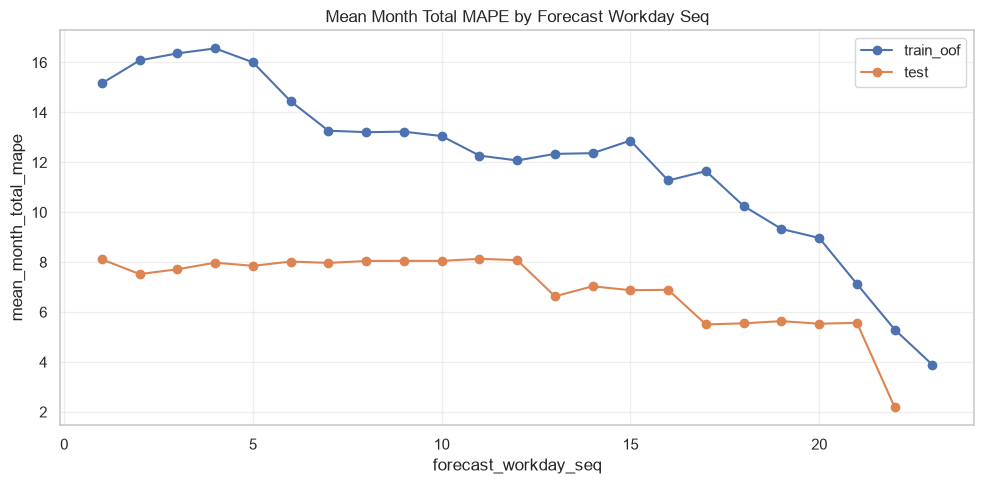

In [9]:
# Block 6.1 - Workday-Level MAPE by Forecast Workday Seq
plot_splits = [split for split in ["train_oof", "valid", "test"] if split in set(workday_mape_summary["split"])]
plot_df = workday_mape_summary[
    workday_mape_summary["split"].isin(plot_splits)
].copy()

plt.figure(figsize=(10, 5))

for split in plot_splits:
    split_df = plot_df[plot_df["split"].eq(split)].sort_values("forecast_workday_seq")
    plt.plot(
        split_df["forecast_workday_seq"],
        split_df["mean_month_total_mape"],
        marker="o",
        label=split,
    )

plt.xlabel("forecast_workday_seq")
plt.ylabel("mean_month_total_mape")
plt.title("Mean Month Total MAPE by Forecast Workday Seq")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# Block 6.2 - SHAP Feature Contribution Analysis: Top 80% Cumulative Features

SHAP_BACKGROUND_MAX_ROWS = 200
SHAP_ANALYSIS_MAX_ROWS = 500
SHAP_TOP_CUMULATIVE_PCT = 0.80

shap_feature_columns = list(best_model_artifact["selected_features"])
shap_model = best_model_artifact["model"]

# Prefer out-of-sample test rows for interpretation; fall back to valid/train when needed.
if not test_monthly_fe.empty:
    shap_analysis_source = test_monthly_fe.copy()
    shap_analysis_split = "test"
elif not valid_monthly_fe.empty:
    shap_analysis_source = valid_monthly_fe.copy()
    shap_analysis_split = "valid"
else:
    shap_analysis_source = train_monthly_fe.copy()
    shap_analysis_split = "train"

shap_background_source = artifact_train_data.copy()

X_shap_background = (
    shap_background_source[shap_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)
X_shap_analysis = (
    shap_analysis_source[shap_feature_columns]
    .replace([np.inf, -np.inf], np.nan)
    .copy()
)

if len(X_shap_background) > SHAP_BACKGROUND_MAX_ROWS:
    X_shap_background = X_shap_background.sample(
        SHAP_BACKGROUND_MAX_ROWS,
        random_state=CONFIG.random_seed,
    )

if len(X_shap_analysis) > SHAP_ANALYSIS_MAX_ROWS:
    X_shap_analysis = X_shap_analysis.sample(
        SHAP_ANALYSIS_MAX_ROWS,
        random_state=CONFIG.random_seed,
    )

print(
    f"Running SHAP for {best_model_artifact['candidate_name']} "
    f"on {shap_analysis_split} split: "
    f"{len(X_shap_analysis)} rows, {len(shap_feature_columns)} features"
)

shap_explainer = shap.Explainer(
    shap_model.predict,
    X_shap_background,
    feature_names=shap_feature_columns,
    seed=CONFIG.random_seed,
)

shap_values = shap_explainer(X_shap_analysis)

shap_value_array = np.asarray(shap_values.values)
if shap_value_array.ndim == 3:
    shap_value_array = shap_value_array[:, :, 0]

shap_importance = pd.DataFrame({
    "feature_name": shap_feature_columns,
    "mean_abs_shap": np.abs(shap_value_array).mean(axis=0),
})
shap_importance["contribution_pct"] = (
    shap_importance["mean_abs_shap"] / shap_importance["mean_abs_shap"].sum()
)
shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False,
).reset_index(drop=True)
shap_importance["cumulative_contribution_pct"] = shap_importance["contribution_pct"].cumsum()

top80_mask = shap_importance["cumulative_contribution_pct"].le(SHAP_TOP_CUMULATIVE_PCT)
if not top80_mask.any():
    top80_mask.iloc[0] = True

# Include the first feature that crosses 80%, so the displayed set reaches at least 80%.
first_over_80_idx = shap_importance.index[
    shap_importance["cumulative_contribution_pct"].ge(SHAP_TOP_CUMULATIVE_PCT)
]
if len(first_over_80_idx) > 0:
    top80_mask.iloc[first_over_80_idx[0]] = True

top80_shap_features = shap_importance.loc[top80_mask, "feature_name"].tolist()
top80_feature_idx = [shap_feature_columns.index(col) for col in top80_shap_features]

top80_shap_values = shap_values[:, top80_feature_idx]

print(
    f"Top {len(top80_shap_features)} features explain "
    f"{shap_importance.loc[top80_mask, 'contribution_pct'].sum():.1%} "
    "of mean absolute SHAP contribution."
)

display(
    shap_importance.loc[top80_mask, [
        "feature_name",
        "mean_abs_shap",
        "contribution_pct",
        "cumulative_contribution_pct",
    ]]
)

plt.figure(figsize=(10, max(5, len(top80_shap_features) * 0.28)))
sns.barplot(
    data=shap_importance.loc[top80_mask].sort_values("mean_abs_shap", ascending=True),
    x="mean_abs_shap",
    y="feature_name",
    color="#4C78A8",
)
plt.xlabel("Mean |SHAP value|")
plt.ylabel("")
plt.title("Top SHAP Features Covering 80% Cumulative Contribution")
plt.tight_layout()
plt.show()

shap.plots.beeswarm(
    top80_shap_values,
    max_display=len(top80_shap_features),
    show=True,
)

Running SHAP for lightgbm_raw on test split: 80 rows, 100 features


NameError: name 'shap' is not defined